In [1]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import os



Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/davisbrown/opt/anaconda3/envs/trans/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [77]:
topic_to_group = {
    # Energy & Environment
    'energy storage': 'Energy & Environ',
    'economics and energy': 'Energy & Environ',
    'energy': 'Energy & Environ',
    'energy and environment': 'Energy & Environ',
    'energy policy and sustainability': 'Energy & Environ',
    'environment and sustainability': 'Energy & Environ',
    'environment and business': 'Energy & Environ',
    'environment and technology': 'Energy & Environ',
    'environmental impact and technology': 'Energy & Environ',
    'environmental sustainability and tech industry': 'Energy & Environ',
    'environment and operations': 'Energy & Environ',
    'electric vehicle manufacturing': 'Energy & Environ',
    'climate change and food security': 'Energy & Environ',
    'renewable energy': 'Energy & Environ',
    'environmental factors and tech industry': 'Energy & Environ',
    'electric vehicles and technology': 'Energy & Environ',
    'technology and electric vehicles': 'Energy & Environ',
    'renewable energy and technology': 'Energy & Environ',
    'energy and technology': 'Energy & Environ',
    'renewable energy and tech': 'Energy & Environ',
    'agriculture and climate change': 'Energy & Environ',
    
    # AI & Computer Science
    'technology and regulation': 'Tech & AI',
    'materials science and quantum computing': 'Tech & AI',
    'cryptography': 'Tech & AI',
    'ai and computing': 'Tech & AI',
    'artificial general intelligence': 'Tech & AI',
    'robotics': 'Tech & AI',
    'ai and robotics': 'Tech & AI',
    'cybersecurity': 'Tech & AI',
    'artificial intelligence and quantum computing': 'Tech & AI',
    'quantum computing and ai': 'Tech & AI',
    'tech industry': 'Tech & AI',
    'artificial intelligence and computing': 'Tech & AI',
    'quantum computing and agi': 'Tech & AI',
    
    # Media
    'social media and politics': 'Media',
    'social media and us presidential election': 'Media',
    'social media': 'Media',
    'social media and regulation': 'Media',
    'social media and mental health': 'Media',
    'election misinformation': 'Media',
    'social media regulation': 'Media',
    'marketing and e-commerce': 'Media',
    'elections and misinformation': 'Media',
    'marketing and social media': 'Media',
    'social media and electric vehicles': 'Media',
    'social media and e-commerce': 'Media',
    'social media and sales': 'Media',
    'politics and social media': 'Media',
    'marketing and consumer behavior': 'Media',
    
    # Transportation
    'autonomous vehicles and transportation': 'Manufacturing',
    'transportation and technology': 'Manufacturing',
    'transportation and infrastructure': 'Manufacturing',
    'transportation and autonomous vehicles': 'Manufacturing',
    'autonomous vehicles': 'Manufacturing',
    'autonomous vehicles and traffic accidents': 'Manufacturing',
    
    # Agriculture & Biotechnology
    'agriculture and biotechnology': 'Ag & Biotech',
    'agriculture and genetic engineering': 'Ag & Biotech',
    'genetic engineering': 'Ag & Biotech',
    'biotechnology and healthcare': 'Ag & Biotech',
    
    # Sports
    'sports': 'Sports',
    'sports and olympics': 'Sports',
    
    # Global Events / Politics / Economics
    'global events and supply chains': 'Politics & Econ',
    'economics': 'Politics & Econ',
    'economics and finance': 'Politics & Econ',
    'economics and technology': 'Politics & Econ',
    'economics and education': 'Politics & Econ',
    'economic sanctions and international trade': 'Politics & Econ',
    'geopolitics': 'Politics & Econ',
    'geopolitics and national security': 'Politics & Econ',
    'politics and social media': 'Politics & Econ',
    'international trade and economic sanctions': 'Politics & Econ',
    'economic sanctions and trade': 'Politics & Econ',
    'geopolitics and international trade': 'Politics & Econ',
}

In [28]:
def load_and_combine_model_datasets(base_path: str, model_names: list[str]) -> pd.DataFrame:
    """
    Load CSV files for each model and combine them into a single DataFrame with model labels.
    
    Args:
        base_path: Base directory path containing the CSV files
        model_names: List of model names to process
        
    Returns:
        Combined DataFrame with generator model labels
    """
    all_dfs = []
    
    for model in model_names:
        file_path = os.path.join(base_path, f"{model}_dataset.csv")
        print(file_path)
        try:
            df = pd.read_csv(file_path, index_col=0)
            # Add generator model name as a column
            df['generator_model'] = model
            all_dfs.append(df)
        except FileNotFoundError:
            print(f"Warning: Could not find dataset for {model} at {file_path}")
    
    # Combine all dataframes
    combined_df = pd.concat(all_dfs, ignore_index=True)
    return combined_df

# Load and combine all datasets
base_path = "./"
model_names = ['gpt-4o', 'deepseek-v3', 'llama_8b', 'llama_70b', 'o1_mini', 'sonnet', 'gpt-4o-mini']

combined_df = load_and_combine_model_datasets(base_path, model_names)

./gpt-4o_dataset.csv
./deepseek-v3_dataset.csv
./llama_8b_dataset.csv
./llama_70b_dataset.csv
./o1_mini_dataset.csv
./sonnet_dataset.csv
./gpt-4o-mini_dataset.csv


In [3]:
combined_df.generator_model.value_counts()

generator_model
o1_mini        210
deepseek-v3    201
llama_70b      201
sonnet         198
llama_8b       186
gpt-4o-mini    186
gpt-4o         123
Name: count, dtype: int64

In [4]:
logical_and_df = combined_df[combined_df.question_type == "P_and_Q"]
logical_and_df.head()

,question_triple_id,iteration,hypothesis,topic,reasoning_flaw,question_type,question_title,question_body,avg_forecast,individual_forecasts,consistency_score,generation_reasoning,generator_model
2,iter4_h2_q0,4,The model overestimates neuromorphic chip adop...,Autonomous Vehicles,NaN,P_and_Q,Loihi 3 efficiency AND Waymo deployment?,Resolves YES per both criteria with benchmark ...,0.63,"[0.65, 0.65, 0.75, 0.45, 0.65]",1.174782,NaN,gpt-4o
3,iter6_h1_q1,6,The model overestimates CRISPR-Cas13 viral sup...,Neuromorphic Computing,NaN,P_and_Q,Intel Smaug success AND Tesla deployment?,Resolves YES per both criteria with benchmark ...,0.63,"[0.65, 0.65, 0.55, 0.65, 0.65]",1.110622,NaN,gpt-4o
6,iter5_h2_q0,5,The model overestimates topological qubit cohe...,Quantum Computing,NaN,P_and_Q,Microsoft coherence AND Quantinuum deployment?,Resolves YES per both criteria with coherence ...,0.66,"[0.65, 0.7, 0.65, 0.65, 0.65]",1.025252,NaN,gpt-4o
9,iter4_h4_q0,4,The model overestimates exascale computing imp...,Nuclear Fusion,NaN,P_and_Q,Frontier SPARC accuracy AND ARC Q≥30?,Resolves YES per both criteria with simulation...,0.56,"[0.65, 0.45, 0.7, 0.65, 0.35]",0.956987,NaN,gpt-4o
14,iter6_h0_q0,6,The model overestimates AI safety certificatio...,AI Governance,NaN,P_and_Q,Claude 5 certification AND EU health mandate?,Resolves YES per both criteria with certificat...,0.49,"[0.45, 0.45, 0.45, 0.65, 0.45]",0.898664,NaN,gpt-4o


./gpt-4o_dataset.csv
./deepseek-v3_dataset.csv
./o1_mini_dataset.csv
./llama_70b_dataset.csv


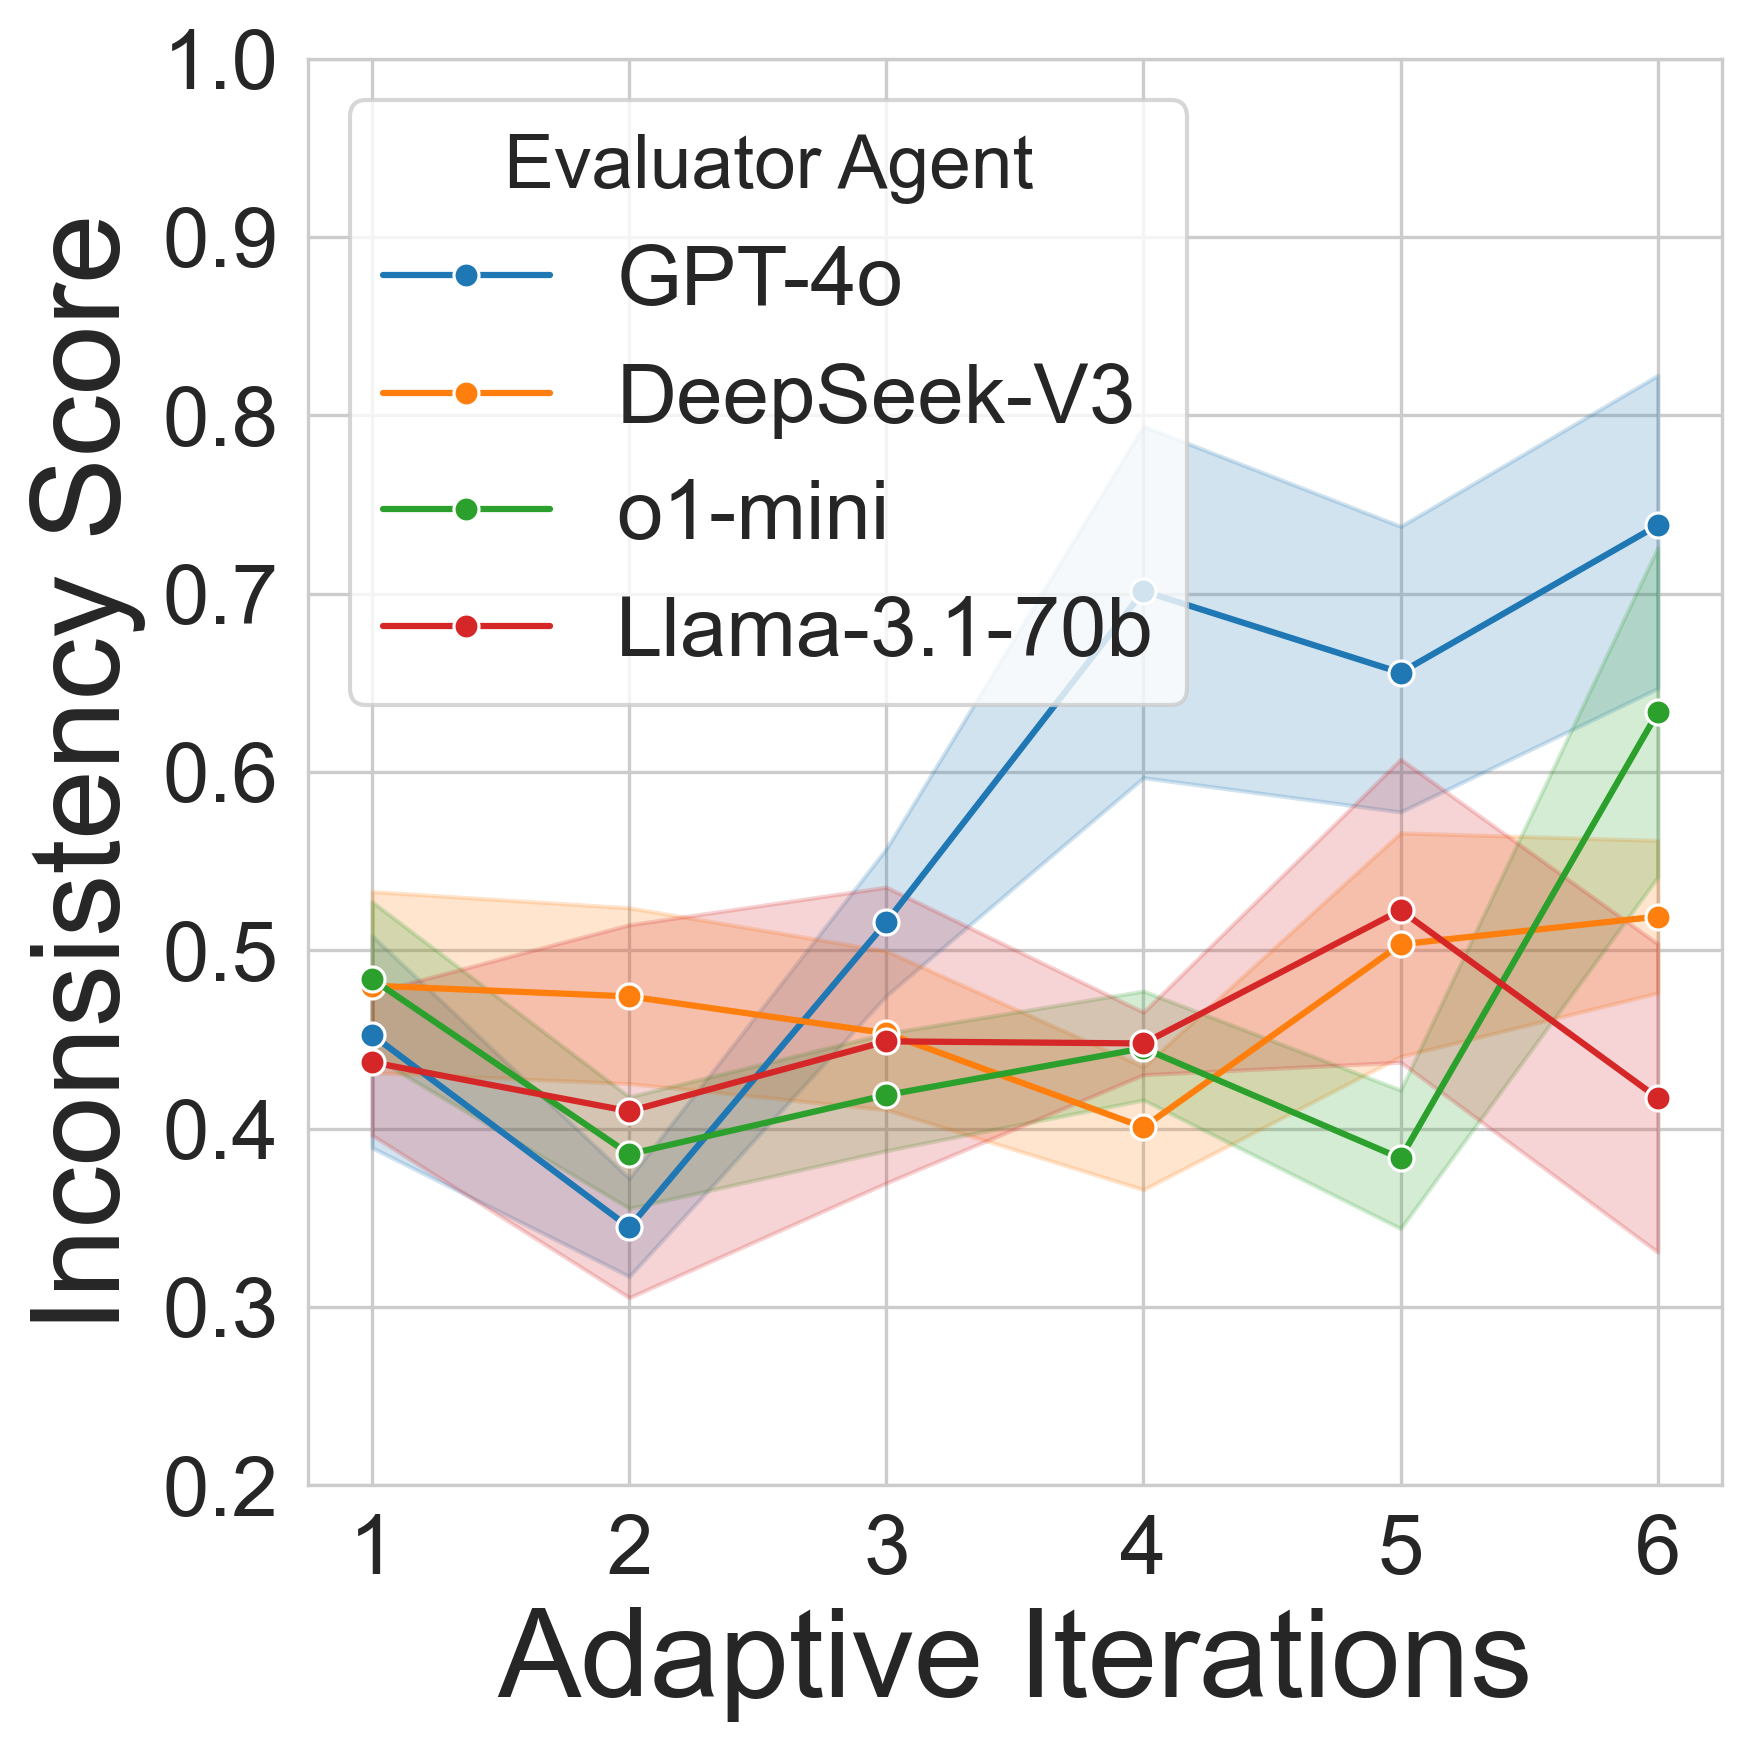

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt


# Set style for paper-quality plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 30,
    'axes.titlesize': 16,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20,
    'legend.title_fontsize': 18
})
# Create figure with higher DPI for paper quality
plt.figure(figsize=(6, 6), dpi=300)

model_names = ['gpt-4o', 'deepseek-v3', 'o1_mini', "llama_70b"]
combined_df = load_and_combine_model_datasets(base_path, model_names)
logical_and_df = combined_df[combined_df.question_type == "P_and_Q"]
logical_and_df = logical_and_df[logical_and_df.iteration < 7]
logical_and_df["stylized_generator_names"] = logical_and_df["generator_model"].map({"gpt-4o": "GPT-4o", "o1_mini": "o1-mini", "deepseek-v3": "DeepSeek-V3", "llama_70b": "Llama-3.1-70b",})

sns.lineplot(
    logical_and_df, x = "iteration", y = "consistency_score", hue="stylized_generator_names" , marker="o", err_style="band", errorbar=('ci', 75)
)
plt.xlabel("Adaptive Iterations",)
plt.ylabel("Inconsistency Score")
plt.ylim(0.2, 1)
plt.legend(title="Evaluator Agent")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("optimization-adaptive.pdf",)

In [66]:
def load_and_combine_model_csv_files(model_dirs: list[str], first_file_only: bool = False, second_file_only: bool = False) -> pd.DataFrame:
    """
    Load and combine CSV files from model-specific directories into a single DataFrame.
    
    Args:
        model_dirs: List of model directory names (e.g., ['gpt-4o', 'deepseek-v3'])
        first_file_only: If True, only load the first CSV file for each model
        second_file_only: If True, only load the second CSV file for each model
        
    Returns:
        Combined DataFrame with generator model labels and properly sequenced iterations
    """
    all_dfs = []
    
    for model_dir in model_dirs:
        print(f"Processing model: {model_dir}")
        model_path = os.path.join("./", model_dir)
        
        if not os.path.isdir(model_path):
            print(f"Warning: Directory not found for {model_dir} at {model_path}")
            continue
        
        csv_files = sorted([f for f in os.listdir(model_path) if f.endswith('.csv')])
        
        if not csv_files:
            print(f"Warning: No CSV files found for {model_dir} in {model_path}")
            continue
        
        # Select files based on options
        if first_file_only and csv_files:
            csv_files = [csv_files[0]]
            print(f"  Loading only first file: {csv_files[0]}")
        elif second_file_only and len(csv_files) > 1:
            csv_files = [csv_files[1]]
            print(f"  Loading only second file: {csv_files[0]}")
        else:
            print(f"  Found {len(csv_files)} CSV files: {csv_files}")
        
        model_dfs = []
        max_iteration = 0
        
        for csv_file in csv_files:
            file_path = os.path.join(model_path, csv_file)
            try:
                df = pd.read_csv(file_path)
                
                # Adjust iteration numbers for subsequent files
                if model_dfs and 'iteration' in df.columns:
                    df['iteration'] = df['iteration'] + max_iteration
                
                model_dfs.append(df)
                
                # Update max_iteration for next file
                if 'iteration' in df.columns and not df['iteration'].empty:
                    file_max_iter = df['iteration'].max()
                    if not pd.isna(file_max_iter):
                        max_iteration = max(max_iteration, file_max_iter + 1)
                
            except Exception as e:
                print(f"  Error loading {file_path}: {e}")
        
        if not model_dfs:
            continue
            
        # Combine all dataframes for this model
        model_df = pd.concat(model_dfs, ignore_index=True)
        
        # Add generator model name if not present
        if 'generator_model' not in model_df.columns:
            model_df['generator_model'] = model_dir
            
        all_dfs.append(model_df)
        print(f"  Successfully loaded {len(model_dfs)} files for {model_dir}")
        
    if not all_dfs:
        raise ValueError("No data was loaded from any model directory")
        
    # Combine all model dataframes
    combined_df = pd.concat(all_dfs, ignore_index=True)
    
    # Print summary statistics
    print("\nData loading summary:")
    print(f"Total rows: {len(combined_df)}")
    
    if 'generator_model' in combined_df.columns:
        print("Rows per model:")
        print(combined_df['generator_model'].value_counts())
        
    if 'iteration' in combined_df.columns:
        print("Rows per iteration:")
        print(combined_df['iteration'].value_counts().sort_index())
        
    return combined_df

Processing model: gpt-4o
  Loading only first file: gpt_4o_20250128_200117.csv
  Successfully loaded 1 files for gpt-4o
Processing model: deepseek-v3
  Loading only first file: deepseek_chat_20250127_124630.csv
  Successfully loaded 1 files for deepseek-v3
Processing model: o1-mini
  Loading only first file: o1_mini_20250127_042817.csv
  Successfully loaded 1 files for o1-mini
Processing model: llama_70b
  Loading only first file: meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv
  Successfully loaded 1 files for llama_70b

Data loading summary:
Total rows: 1260
Rows per model:
generator_model
gpt-4o         390
llama_70b      360
o1-mini        300
deepseek-v3    210
Name: count, dtype: int64
Rows per iteration:
iteration
1     120
2     120
3     120
4     120
5     120
6     120
7     120
8      90
9      90
10     90
11     60
12     60
13     30
Name: count, dtype: int64


/var/folders/gs/b4944zy9317b52hl9zw3rbnh0000gn/T/ipykernel_16343/3837742349.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



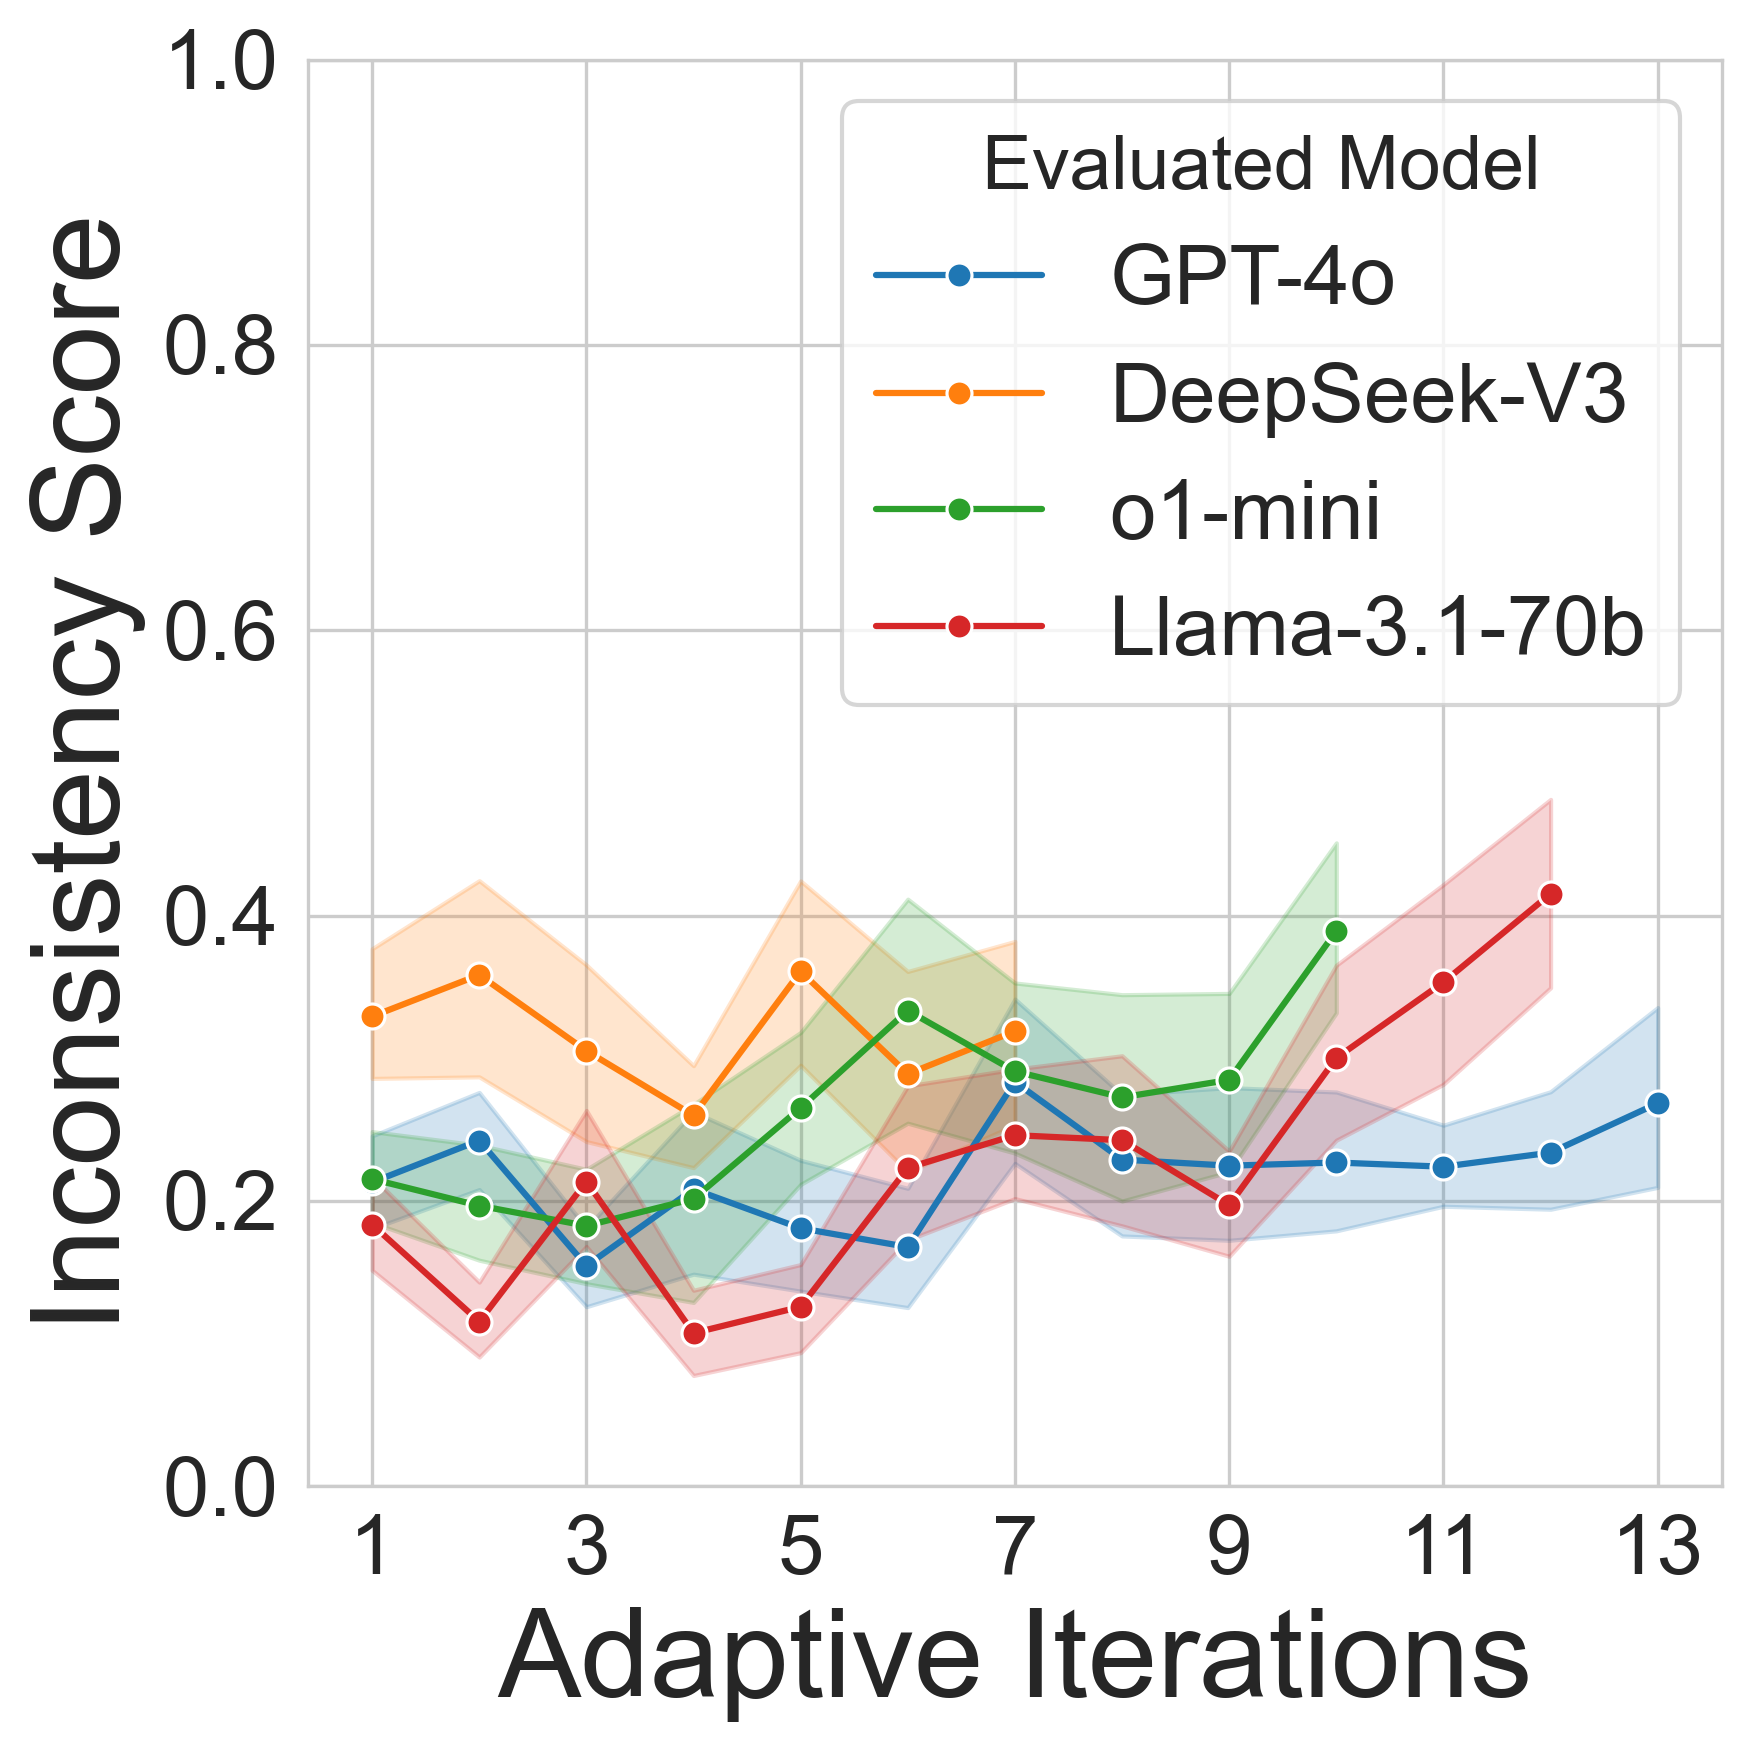

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt


# Set style for paper-quality plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 30,
    'axes.titlesize': 16,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20,
    'legend.title_fontsize': 18
})
# Create figure with higher DPI for paper quality
plt.figure(figsize=(6, 6), dpi=300)

model_names = ['gpt-4o', 'deepseek-v3', 'o1-mini', "llama_70b"]
combined_df = load_and_combine_model_csv_files(model_names, first_file_only=True)
logical_and_df = combined_df[combined_df.question_type == "P_and_Q"]
# logical_and_df = logical_and_df[logical_and_df.iteration < 10]
logical_and_df["stylized_generator_names"] = logical_and_df["generator_model"].map({"gpt-4o": "GPT-4o", "o1-mini": "o1-mini", "deepseek-v3": "DeepSeek-V3", "llama_70b": "Llama-3.1-70b",})

sns.lineplot(
    logical_and_df, x = "iteration", y = "consistency_score", hue="stylized_generator_names" , marker="o", err_style="band", errorbar=('ci', 75)
)
plt.xlabel("Adaptive Iterations",)
plt.ylabel("Inconsistency Score")
plt.ylim(0., 1)
plt.legend(title="Evaluated Model")
plt.xticks(range(int(logical_and_df["iteration"].min()), int(logical_and_df["iteration"].max())+1, 2), fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("consistency-brute-force.pdf",)

Processing model: llama_70b
  Loading only first file: meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv
  Successfully loaded 1 files for llama_70b

Data loading summary:
Total rows: 360
Rows per model:
generator_model
llama_70b    360
Name: count, dtype: int64
Rows per iteration:
iteration
1     30
2     30
3     30
4     30
5     30
6     30
7     30
8     30
9     30
10    30
11    30
12    30
Name: count, dtype: int64


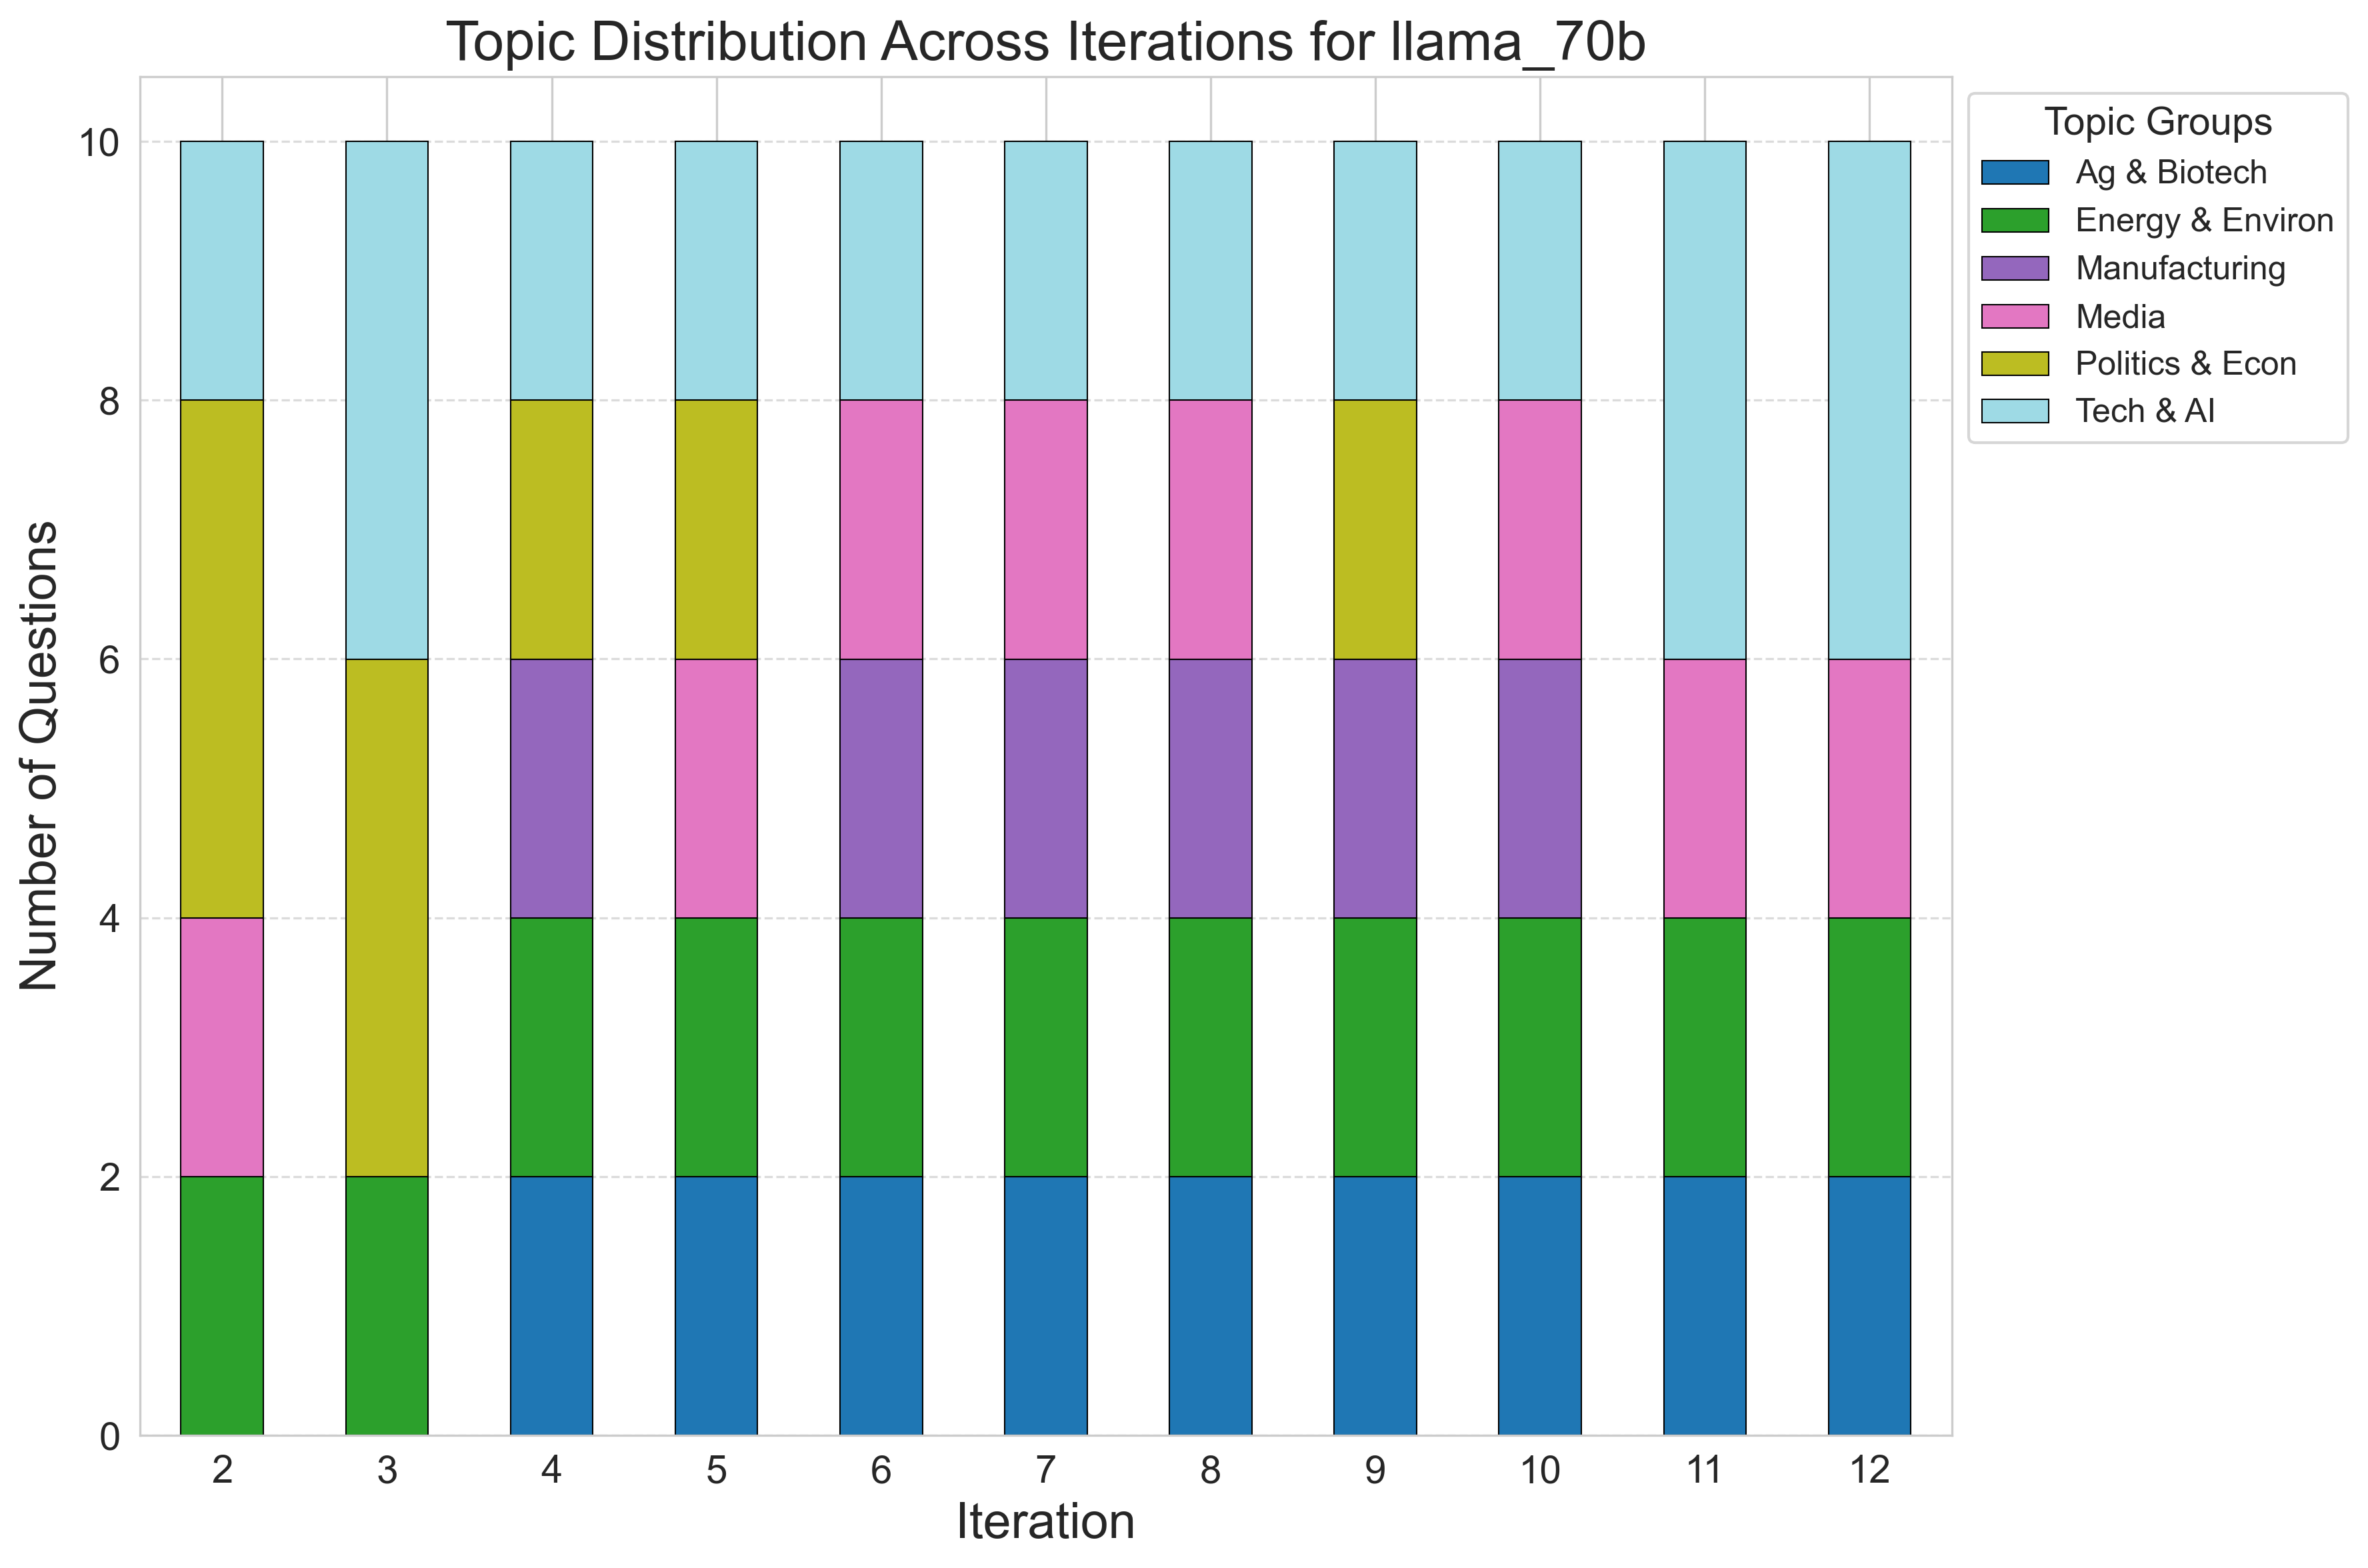

Topic distribution summary:
topic_group  Ag & Biotech  Energy & Environ  Manufacturing  Media  \
iteration                                                           
2                       0                 2              0      2   
3                       0                 2              0      0   
4                       2                 2              2      0   
5                       2                 2              0      2   
6                       2                 2              2      2   
7                       2                 2              2      2   
8                       2                 2              2      2   
9                       2                 2              2      0   
10                      2                 2              2      2   
11                      2                 2              0      2   
12                      2                 2              0      2   

topic_group  Politics & Econ  Tech & AI  
iteration                       

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import os


def plot_topic_distribution_by_iteration(combined_df: pd.DataFrame, 
                                         model_name: str = None,
                                         topic_column: str = 'topic',
                                         figsize: tuple = (12, 8),
                                         save_path: str = None) -> None:
    """
    Create a stacked bar plot showing the distribution of topics across iterations.
    
    Args:
        combined_df: DataFrame containing the data
        model_name: If provided, filter data to only this model
        topic_column: Column name containing topic information
        figsize: Figure size as (width, height)
        save_path: If provided, save the figure to this path
    """
    # Filter for P_and_Q questions
    df = combined_df[combined_df.question_type == "P_and_Q"].copy()
    
    # Filter for specific model if requested
    if model_name:
        df = df[df.generator_model == model_name]
    
    # Clean up topic values
    df[topic_column] = df[topic_column].fillna('Unlabeled')
    
    # Map topics to broader categories for better visualization
    # Apply the mapping
    df['topic_group'] = df[topic_column].str.lower().map(topic_to_group).fillna('Other')
    
    # Count questions by iteration and topic group
    topic_counts = df.groupby(['iteration', 'topic_group']).size().unstack(fill_value=0)
    
    # Ensure all iterations are represented (even if they have no data)
    all_iterations = range(int(df['iteration'].min()), int(df['iteration'].max()) + 1)
    topic_counts = topic_counts.reindex(all_iterations, fill_value=0)
    
    # Set up the plot with paper-quality settings
    plt.figure(figsize=figsize, dpi=300)
    ax = plt.gca()
    
    # Create the stacked bar plot
    topic_counts.plot(kind='bar', stacked=True, ax=ax, 
                     colormap='tab20', 
                     edgecolor='black', 
                     linewidth=0.5)
    
    # Customize the plot
    title = f"Topic Distribution Across Iterations"
    if model_name:
        title += f" for {model_name}"
    
    plt.title(title, fontsize=20)
    plt.xlabel("Iteration", fontsize=18)
    plt.ylabel("Number of Questions", fontsize=18)
    plt.xticks(fontsize=14, rotation=0)
    plt.yticks(fontsize=14)
    
    # Add a grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Customize the legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title="Topic Groups", 
              loc='upper left', bbox_to_anchor=(1, 1), 
              fontsize=12, title_fontsize=14)
    
    plt.tight_layout()
    
    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    plt.show()
    
    # Print summary statistics
    print(f"Topic distribution summary:")
    print(topic_counts)
    
    # Calculate and print percentages
    topic_percentages = topic_counts.div(topic_counts.sum(axis=1), axis=0) * 100
    print("\nTopic distribution percentages:")
    print(topic_percentages.round(1))

# Example usage:
# Load data using the previously defined function
# model_dirs = ['deepseek-v3', 'llama_70b', 'o1-mini', 'gpt-4o']
model_dirs = ['llama_70b']
combined_df = load_and_combine_model_csv_files(model_dirs, first_file_only=True)

# Create stacked bar plot for all models combined
# plot_topic_distribution_by_iteration(combined_df, save_path="topic_distribution_all_models.png")

# Create individual plots for each model
for model in model_dirs:
    plot_topic_distribution_by_iteration(
        combined_df, 
        model_name=model,
        save_path=f"topic_distribution_{model}.png"
    )

Processing model: llama_70b
  Found 2 CSV files: ['meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv', 'meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_232333.csv']
  Successfully loaded 2 files for llama_70b

Data loading summary:
Total rows: 525
Rows per model:
generator_model
llama_70b    525
Name: count, dtype: int64
Rows per iteration:
iteration
1     30
2     30
3     30
4     30
5     30
6     30
7     30
8     30
9     30
10    30
11    30
12    30
14    45
15    30
16    30
17    30
18    30
Name: count, dtype: int64


Analyzing model: llama_70b
Found 52 unique topics in dataset
Successfully mapped 525 out of 525 topics (100.0%)

Topic group distribution:
topic_group
Tech & AI           159
Energy & Environ    117
Media                69
Ag & Biotech         66
Politics & Econ      63
Manufacturing        36
Sports               15
Name: count, dtype: int64


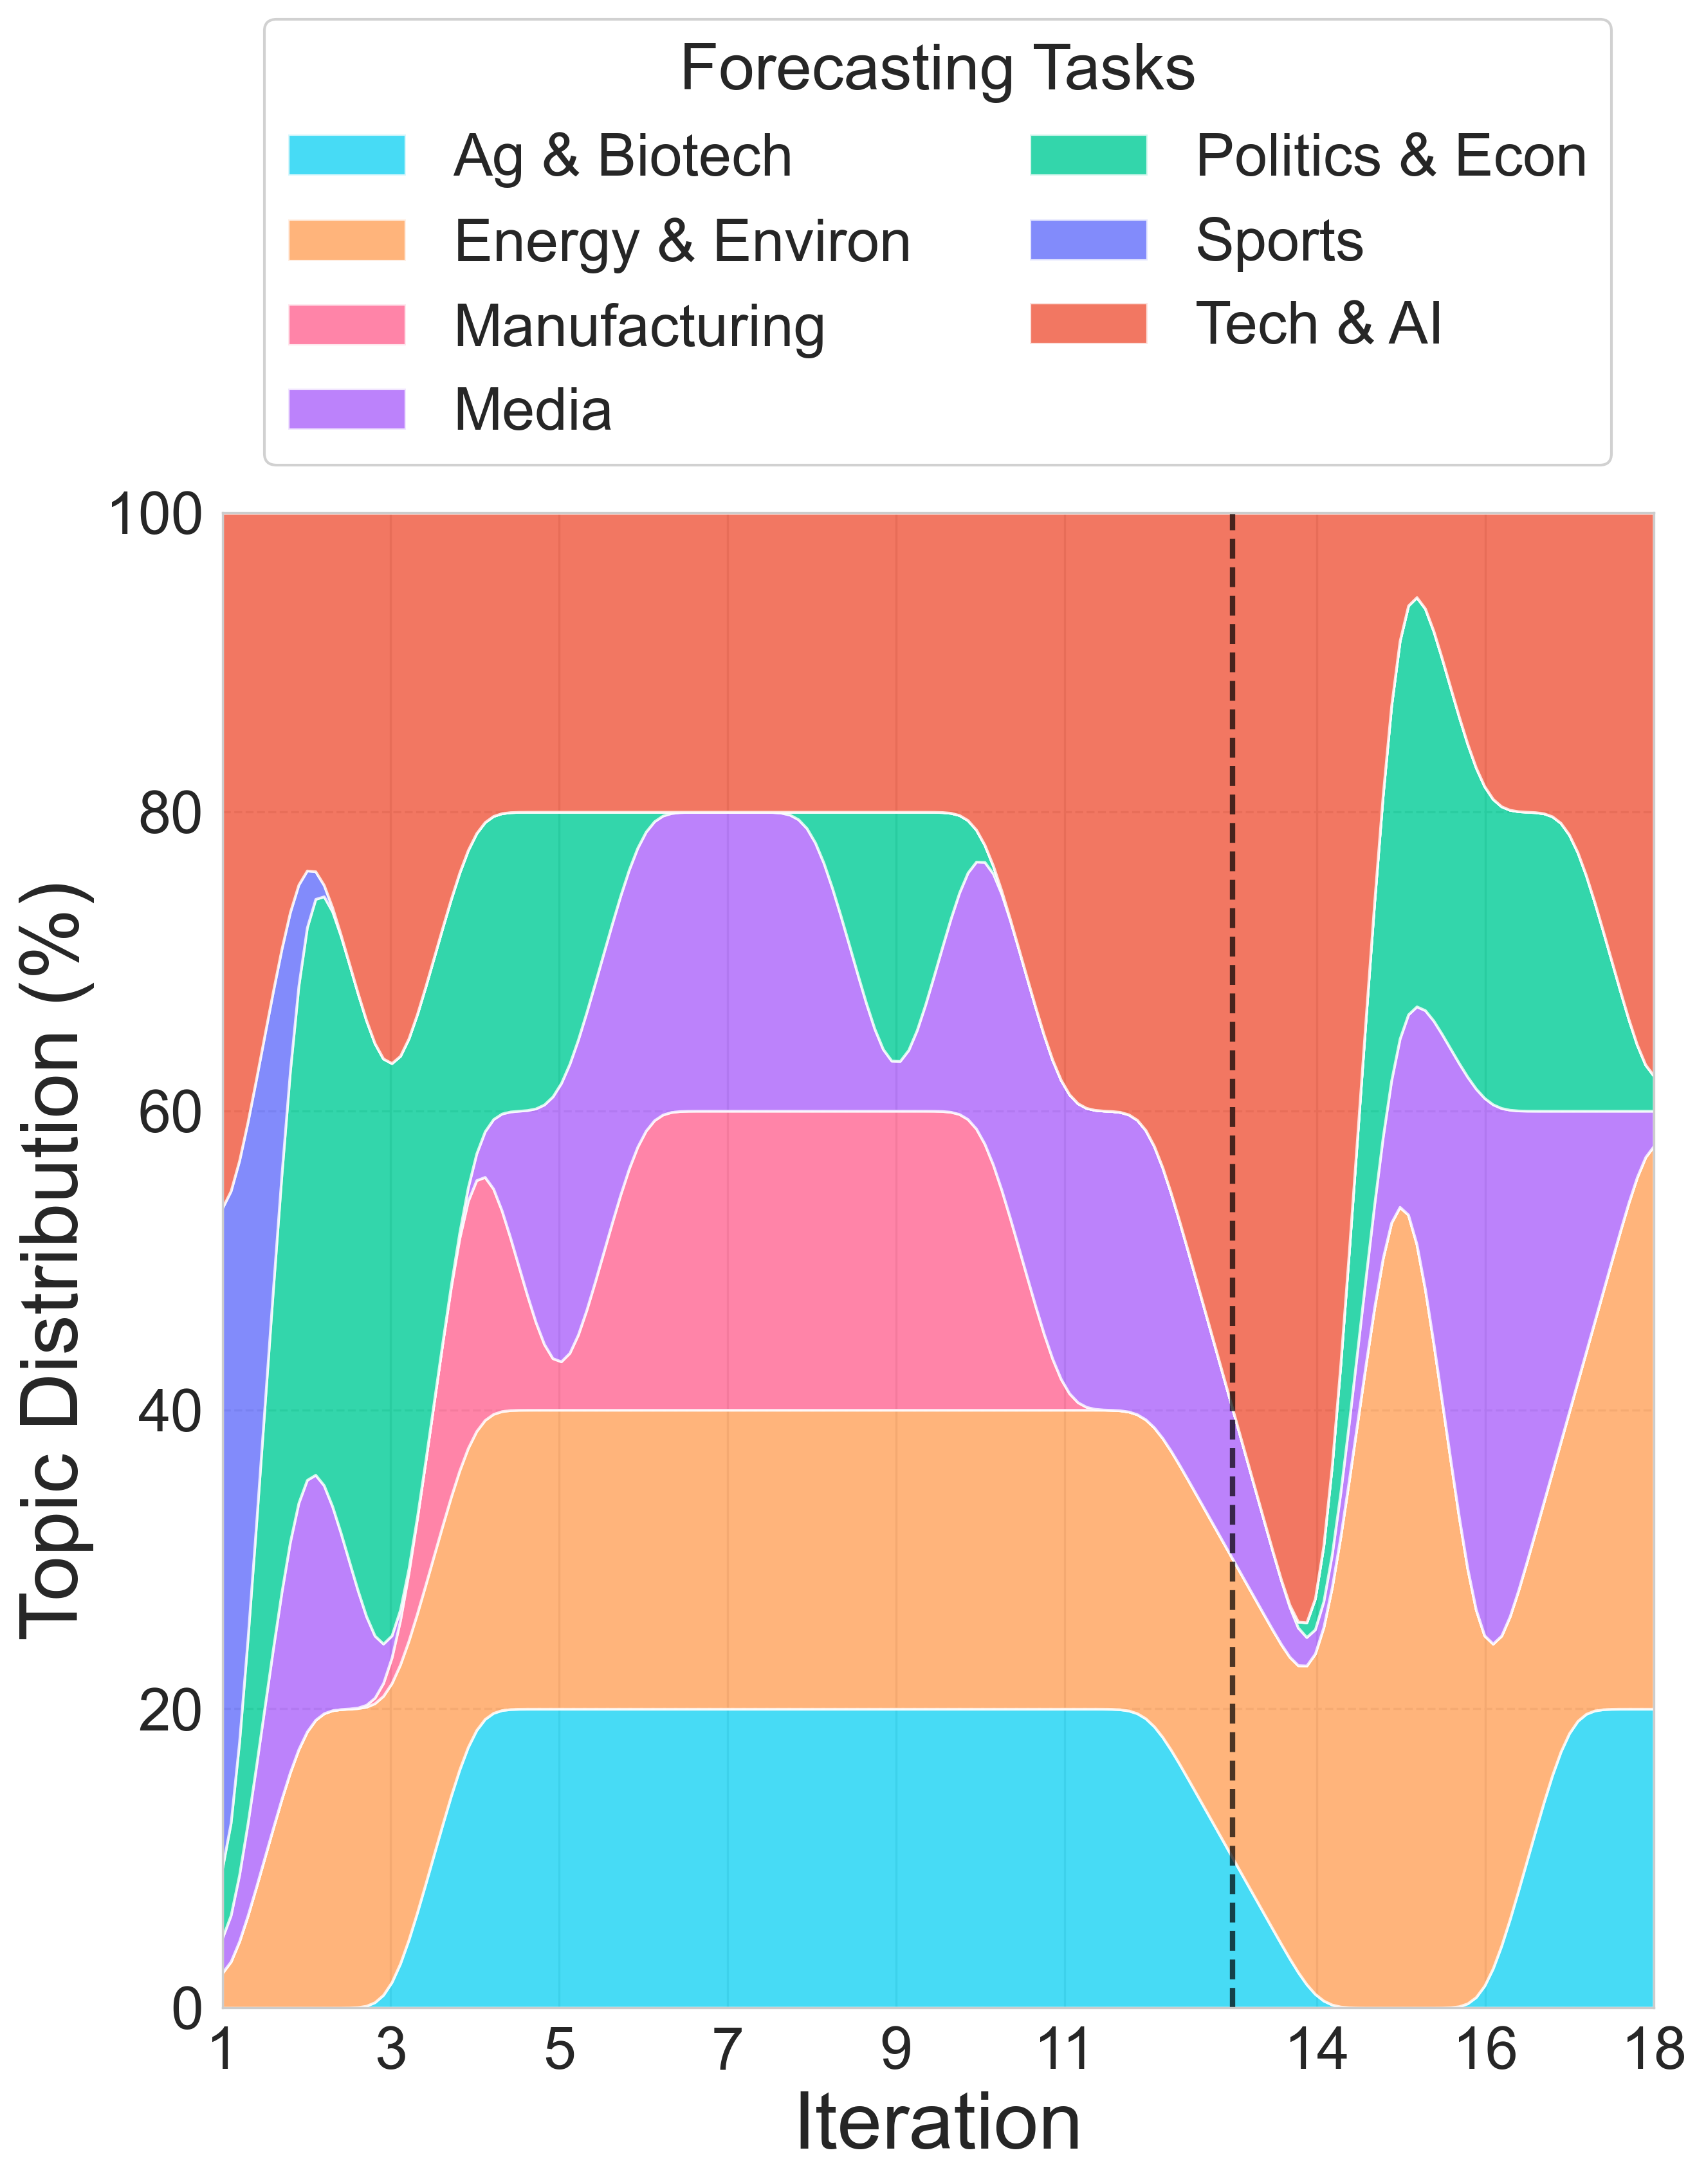

In [139]:
def visualize_topic_evolution_with_smoothing(combined_df: pd.DataFrame, 
                                           model_name: str = None,
                                           topic_column: str = 'topic',
                                           smoothing_window: int = 2,
                                           save_path_prefix: str = None):
    """
    Create a streamgraph visualization showing topic evolution across iterations with smoothing.
    
    Args:
        combined_df: DataFrame containing the data
        model_name: If provided, filter data to only this model
        topic_column: Column name containing topic information
        smoothing_window: Window size for moving average smoothing
        save_path_prefix: If provided, save figures with this prefix
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    from scipy.ndimage import gaussian_filter1d
    sns.set_style("whitegrid")
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 30,
        'axes.titlesize': 16,
        'xtick.labelsize': 18,
        'ytick.labelsize': 18,
        'legend.fontsize': 16,  # Reduced from 20 to 14
        'legend.title_fontsize': 16  # Reduced from 18 to 16
    })
    
    # Filter for P_and_Q questions
    # df = combined_df[combined_df.question_type == "P_and_Q"].copy()
    df = combined_df.copy()
    
    # Filter for specific model if requested
    if model_name:
        df = df[df.generator_model == model_name]
        title_suffix = f" for {model_name}"
    else:
        title_suffix = " (All Models)"
    
    # Clean up topic values
    df[topic_column] = df[topic_column].fillna('Unlabeled')
    
    # Print unique topics to debug
    print(f"Found {len(df[topic_column].unique())} unique topics in dataset")
    
    # Map topics to broader categories
    # Apply the mapping with case-insensitive matching
    df['topic_group'] = df[topic_column].str.lower().map(topic_to_group)
    
    # Check how many were mapped successfully
    mapped_count = df['topic_group'].notna().sum()
    total_count = len(df)
    print(f"Successfully mapped {mapped_count} out of {total_count} topics ({mapped_count/total_count*100:.1f}%)")
    
    # Fill unmapped topics with 'Other'
    df['topic_group'] = df['topic_group'].fillna('Other')
    
    # Print topic group distribution
    print("\nTopic group distribution:")
    print(df['topic_group'].value_counts())
    
    # Count questions by iteration and topic group
    topic_counts = df.groupby(['iteration', 'topic_group']).size().unstack(fill_value=0)
    
    # Ensure all iterations are represented
    all_iterations = sorted(df['iteration'].unique())
    topic_counts = topic_counts.reindex(all_iterations, fill_value=0)
    
    # Calculate percentages
    topic_percentages = topic_counts.div(topic_counts.sum(axis=1), axis=0) * 100
    
    # Apply Gaussian smoothing if we have enough data points
    if len(all_iterations) >= 3:
        # Create a finer x-axis for smoother curves
        x_smooth = np.linspace(min(all_iterations), max(all_iterations), 
                              num=max(100, len(all_iterations) * 10))
        
        # Smooth each topic's percentage curve using Gaussian filter
        smoothed_percentages = {}
        for topic in topic_percentages.columns:
            y = topic_percentages[topic].values
            
            # Interpolate to get values at the smooth x points
            y_interp = np.interp(x_smooth, all_iterations, y)
            
            # Apply Gaussian smoothing
            sigma = smoothing_window  # Adjust sigma based on desired smoothing strength
            smoothed_percentages[topic] = gaussian_filter1d(y_interp, sigma=sigma)
    else:
        # Not enough data points for smoothing
        x_smooth = all_iterations
        smoothed_percentages = {topic: topic_percentages[topic].values for topic in topic_percentages.columns}
    
    # Set style for paper-quality plots
    sns.set_style("whitegrid")
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 30,
        'axes.titlesize': 16,
        'xtick.labelsize': 28,
        'ytick.labelsize': 28,
        'legend.fontsize': 18,  # Reduced from 18 to 14
        'legend.title_fontsize': 18  # Reduced from 20 to 16
    })
    # VISUALIZATION: SMOOTHED STREAMGRAPH
    plt.figure(figsize=(9, 12), dpi=300)
    
    # Custom color mapping for topic groups
    color_map = {
        'Sports': '#636efa',
        'Tech & AI': '#EF553B',
        'Politics & Econ': '#00cc96',
        'Media': '#ab63fa',
        'Energy & Environ': '#FFA15A',
        'Ag & Biotech': '#19d3f3',
        'Manufacturing': '#FF6692',
        'Other': '#B6E880',
        'Unlabeled': '#cccccc'  # Light gray for unlabeled topics
    }
    
    # Get colors for each topic in the correct order
    topic_colors = [color_map.get(topic, '#B6E880') for topic in topic_percentages.columns]
    
    # Plot the streamgraph with smoothed data and custom colors
    plt.stackplot(x_smooth, 
                 [smoothed_percentages[topic] for topic in topic_percentages.columns],
                 labels=topic_percentages.columns,
                 colors=topic_colors,
                 alpha=0.8)
    
    # plt.title(f"Topic Evolution Across Iterations{title_suffix}", fontsize=20)
    plt.xlabel("Iteration", fontsize=30)
    plt.ylabel("Topic Distribution (%)", fontsize=30)
    
    # Set x-ticks to show only the original iteration numbers
    # Show only every other iteration on x-axis
    plt.xticks(all_iterations[::2], [str(int(i)) for i in all_iterations[::2]], fontsize=14)
    plt.yticks(fontsize=14)
    
    # Add grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.9)
    
    # Add a vertical dashed line at iteration 13
    if 13 >= min(all_iterations) and 13 <= max(all_iterations):
        plt.axvline(x=13, color='black', linestyle='--', linewidth=2, alpha=0.7)
        # Create a custom legend entry for the vertical line
        from matplotlib.lines import Line2D
        custom_line = Line2D([0], [0], color='black', linestyle='--', linewidth=2)
    
    # Get the existing handles and labels
    handles, labels = plt.gca().get_legend_handles_labels()
    
    # # Add the custom line to the handles and labels
    # if 13 >= min(all_iterations) and 13 <= max(all_iterations):
    #     handles.append(custom_line)
    #     labels.append('End of Brute Force Iterations')
    
    # Add a legend outside the plot with the combined handles and labels
    plt.legend(handles=handles, labels=labels, loc='upper center', bbox_to_anchor=(0.5, 1.35), 
               title="Forecasting Tasks", fontsize=22, ncol=2, framealpha=0.9, title_fontsize=24)
    plt.ylim(0, 100)
    plt.xlim(min(all_iterations), max(all_iterations))
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    
    plt.tight_layout()
    if save_path_prefix:
        plt.savefig(f"{save_path_prefix}_smoothed_streamgraph.pdf", bbox_inches='tight')
    plt.show()
    
    # Return the processed data for further analysis
    return {
        'counts': topic_counts,
        'percentages': topic_percentages,
        'x_smooth': x_smooth,
        'smoothed_percentages': smoothed_percentages
    }

# Example usage:
model_dirs = ['llama_70b'] #, 'deepseek-v3', 'o1-mini', 'gpt-4o']
combined_df = load_and_combine_model_csv_files(model_dirs, first_file_only=False)

# Create visualizations for each model
for model in model_dirs:
    print(f"\n\nAnalyzing model: {model}")
    visualize_topic_evolution_with_smoothing(
        combined_df, 
        model_name=model,
        smoothing_window=2,  # Adjust smoothing strength
        save_path_prefix=f"{model}_topics"
    )

In [140]:
def visualize_topic_evolution_sankey(combined_df: pd.DataFrame,
                                    model_name: str = None,
                                    topic_column: str = 'topic',
                                    max_iterations: int = None,
                                    iteration_step: int = 1,
                                    save_path: str = None):
    """
    Create a Sankey diagram showing topic evolution across iterations.
    
    Args:
        combined_df: DataFrame containing the data
        model_name: If provided, filter data to only this model
        topic_column: Column name containing topic information
        max_iterations: If provided, only include iterations up to this value
        iteration_step: Step size for iterations to include (to avoid overcrowding)
        save_path: If provided, save the figure to this path
    """
    import plotly.graph_objects as go
    import pandas as pd
    import numpy as np
    
    # Filter for specific model if requested
    df = combined_df.copy()
    if model_name:
        df = df[df.generator_model == model_name]
        title_suffix = f" for {model_name}"
    else:
        title_suffix = " (All Models)"
    
    # Clean up topic values
    df[topic_column] = df[topic_column].fillna('Unlabeled')
    
    # Map topics to broader categories
    df['topic_group'] = df[topic_column].str.lower().map(topic_to_group).fillna('Other')
    
    # Filter iterations if requested
    all_iterations = sorted(df['iteration'].unique())
    if max_iterations is not None:
        all_iterations = [i for i in all_iterations if i <= max_iterations]
    
    # Select iterations at specified step size to avoid overcrowding
    selected_iterations = all_iterations[::iteration_step]
    if selected_iterations and selected_iterations[-1] != all_iterations[-1]:
        selected_iterations.append(all_iterations[-1])  # Always include the last iteration
    
    df = df[df['iteration'].isin(selected_iterations)]
    
    # Count questions by iteration and topic group
    topic_counts = df.groupby(['iteration', 'topic_group']).size().reset_index(name='count')
    
    # Prepare data for Sankey diagram
    # We need to create links between consecutive iterations for each topic
    nodes = []
    node_indices = {}
    links = []
    
    # Create nodes for each topic at each iteration
    for i, iteration in enumerate(selected_iterations):
        iteration_topics = topic_counts[topic_counts['iteration'] == iteration]['topic_group'].unique()
        for topic in iteration_topics:
            node_name = f"{topic} (Iter {iteration})"
            nodes.append({"name": node_name})
            node_indices[(iteration, topic)] = len(nodes) - 1
    
    # Create links between consecutive iterations
    for i in range(len(selected_iterations) - 1):
        curr_iter = selected_iterations[i]
        next_iter = selected_iterations[i + 1]
        
        # Get topics and counts for current iteration
        curr_topics = topic_counts[topic_counts['iteration'] == curr_iter]
        
        # Get topics and counts for next iteration
        next_topics = topic_counts[topic_counts['iteration'] == next_iter]
        
        # For each topic in current iteration, distribute its count to topics in next iteration
        for _, curr_row in curr_topics.iterrows():
            curr_topic = curr_row['topic_group']
            curr_count = curr_row['count']
            
            # Get total count in next iteration
            next_total = next_topics['count'].sum()
            
            # Distribute current count proportionally to topics in next iteration
            for _, next_row in next_topics.iterrows():
                next_topic = next_row['topic_group']
                next_count = next_row['count']
                
                # Calculate proportional flow
                if next_total > 0:
                    flow_value = curr_count * (next_count / next_total)
                else:
                    flow_value = 0
                
                # Only add links with non-zero flow
                if flow_value > 0:
                    source_idx = node_indices.get((curr_iter, curr_topic))
                    target_idx = node_indices.get((next_iter, next_topic))
                    
                    if source_idx is not None and target_idx is not None:
                        links.append({
                            "source": source_idx,
                            "target": target_idx,
                            "value": flow_value
                        })
    
    # Custom color mapping for topic groups
    color_map = {
        'Sports': '#636efa',
        'Tech & AI': '#EF553B',
        'Politics & Econ': '#00cc96',
        'Media': '#ab63fa',
        'Energy & Environ': '#FFA15A',
        'Ag & Biotech': '#19d3f3',
        'Manufacturing': '#FF6692',
        'Other': '#B6E880',
        'Unlabeled': '#cccccc'
    }
    
    # Assign colors to nodes based on topic group
    node_colors = []
    for node in nodes:
        topic = node["name"].split(" (Iter ")[0]
        node_colors.append(color_map.get(topic, '#B6E880'))
    
    # Create Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=[node["name"] for node in nodes],
            color=node_colors
        ),
        link=dict(
            source=[link["source"] for link in links],
            target=[link["target"] for link in links],
            value=[link["value"] for link in links],
            # Optional: color links by source node color with some transparency
            color=[f"rgba{tuple(int(node_colors[link['source']][1:][i:i+2], 16) for i in (0, 2, 4)) + (0.4,)}" 
                  for link in links]
        )
    )])
    
    # Update layout
    fig.update_layout(
        title_text=f"Topic Evolution Across Iterations{title_suffix}",
        font_size=12,
        width=1200,
        height=800
    )
    
    # Show the figure
    fig.show()
    
    # Save the figure if a path is provided
    if save_path:
        fig.write_image(save_path, scale=2)
    
    return fig

# Example usage:
model_dirs = ['llama_70b']  # You can add more models if needed
combined_df = load_and_combine_model_csv_files(model_dirs, first_file_only=False)

# Create Sankey diagram for each model
for model in model_dirs:
    print(f"\n\nAnalyzing model: {model}")
    visualize_topic_evolution_sankey(
        combined_df,
        model_name=model,
        max_iterations=None,  # Set to a number to limit iterations
        iteration_step=2,     # Show every 2nd iteration to avoid overcrowding
        save_path=f"{model}_topics_sankey.pdf"
    )

Processing model: llama_70b
  Found 2 CSV files: ['meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv', 'meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_232333.csv']
  Successfully loaded 2 files for llama_70b

Data loading summary:
Total rows: 525
Rows per model:
generator_model
llama_70b    525
Name: count, dtype: int64
Rows per iteration:
iteration
1     30
2     30
3     30
4     30
5     30
6     30
7     30
8     30
9     30
10    30
11    30
12    30
14    45
15    30
16    30
17    30
18    30
Name: count, dtype: int64


Analyzing model: llama_70b


In [86]:
set(combined_df.iteration)
combined_df.tail()

,question_triple_id,iteration,hypothesis,topic,reasoning_flaw,question_type,question_title,question_body,avg_forecast,individual_forecasts,consistency_score,generator_model
520,iter5_h4_q0,18,The model underestimates the impact of genetic...,Genetic Engineering,NaN,Q_given_P,Given the development of a gene editing therap...,"This question resolves as YES if, given the de...",0.62,"[0.62, 0.62, 0.62, 0.62, 0.62]",0.258952,llama_70b
521,iter5_h4_q0,18,The model underestimates the impact of genetic...,Genetic Engineering,NaN,P_and_Q,Will CRISPR Therapeutics develop a gene editin...,This question resolves as YES if both conditio...,0.662,"[0.72, 0.6, 0.72, 0.55, 0.72]",0.258952,llama_70b
522,iter5_h4_q1,18,The model underestimates the impact of genetic...,Genetic Engineering,NaN,P,Will Editas Medicine develop a gene editing th...,This question resolves as YES if Editas Medici...,0.7,"[0.72, 0.72, 0.72, 0.62, 0.72]",0.229819,llama_70b
523,iter5_h4_q1,18,The model underestimates the impact of genetic...,Genetic Engineering,NaN,Q_given_P,Given the development of a gene editing therap...,"This question resolves as YES if, given the de...",0.5,"[0.62, 0.42, 0.62, 0.42, 0.42]",0.229819,llama_70b
524,iter5_h4_q1,18,The model underestimates the impact of genetic...,Genetic Engineering,NaN,P_and_Q,Will Editas Medicine develop a gene editing th...,This question resolves as YES if both conditio...,0.5,"[0.42, 0.42, 0.42, 0.62, 0.62]",0.229819,llama_70b


In [6]:
# # Define topic groupings
# topic_to_group = {
#     # Energy and Environment
#     'energy storage': 'Energy & Environment',
#     'economics and energy': 'Energy & Environment',
#     'energy': 'Energy & Environment',
#     'energy and environment': 'Energy & Environment',
#     'energy policy and sustainability': 'Energy & Environment',
    
#     # Economics
#     'economics': 'Economics',
#     'economics and finance': 'Economics',
    
#     # Politics
#     'geopolitics': 'Politics',
#     'economics and education': 'Politics',
#     'geopolitics and national security': 'Politics',
#     'labor market and technology': 'Politics',
    
#     # Computing
#     'technology and regulation': 'AI & Computer Science',
#     'materials science and quantum computing':  'AI & Computer Science',
#     'cryptography':  'AI & Computer Science',
#     'ai and computing':  'AI & Computer Science',
#     'artificial general intelligence':  'AI & Computer Science',
#     'robotics':  'AI & Computer Science',
#     'ai and robotics':  'AI & Computer Science',
#     'cybersecurity':  'AI & Computer Science',
    
#     #Social Media
#     'social media and politics': 'Media',
#     'social media': 'Media',
#     'social media and regulation': 'Media',
#     'social media and mental health': 'Media',
#     'election misinformation': 'Media',
#     'social media regulation':  'Media',
#     'marketing and e-commerce': 'Media',
#     'elections and misinformation': 'Media',
    
#     # Sports
#     'sports': 'Sports',
#     'sports and olympics': 'Sports'
# }

# def analyze_model_topics(logical_and_df: pd.DataFrame, model_names: list[str]):
#     """
#     Analyze and visualize topic distribution between models using MPNet embeddings and t-SNE.
#     Uses predefined topic groupings for consistent categorization.
#     """
#     # Filter for specified models
#     model_df = logical_and_df[logical_and_df['generator_model'].isin(model_names)]
    
#     # Initialize MPNet model
#     mpnet = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
    
#     # Get embeddings for questions
#     old_texts = model_df['question_body'].tolist()
#     embeddings = mpnet.encode(old_texts, show_progress_bar=True)
#     texts = []
#     for text in old_texts:
#         formatted = ""
#         for i in range(0, len(text), 80):
#             chunk = text[i:i+80]
#             formatted += chunk
#             if i + 80 < len(text):
#                 formatted += "<br>"
#         texts.append(formatted)
    
#     # t-SNE dimensionality reduction
#     tsne = TSNE(n_components=2, perplexity=30, random_state=42)
#     tsne_embeddings = tsne.fit_transform(embeddings)
    
#     # Map topics to groups
#     def get_topic_group(topic):
#         if pd.isna(topic):
#             return 'Other'
#         return topic_to_group.get(topic.lower(), 'Other')
    
#     # Create visualization DataFrame
#     viz_df = pd.DataFrame({
#         'TSNE1': tsne_embeddings[:, 0],
#         'TSNE2': tsne_embeddings[:, 1],
#         'Model': model_df['generator_model'].values,
#         'Question': texts,
#         'Question_Preview': [t[:100] + '...' for t in texts],
#         'Original_Topic': model_df['topic'].values,
#         'Topic_Group': model_df['topic'].apply(get_topic_group)
#     })
    
#     # Define color scheme
# # ... existing code ...

#     # Define color scheme
#     color_map = {
#         'Energy & Environment': '#2ecc71',    # Green
#         'Economics': '#e74c3c',               # Red
#         'Politics': '#3498db',                # Blue
#         'Computing': '#9b59b6',               # Purple
#         'Artificial General Intelligence': '#f1c40f',  # Yellow
#         'Biotechnology': '#1abc9c',           # Turquoise
#         'Sports': '#e67e22',                  # Orange
#         'Other': 'rgba(149, 165, 166, 0.5)'  # Semi-transparent grey
#     }

# # ... existing code ...    
#         # Create interactive plot
#     fig = px.scatter(
#         viz_df,
#         x='TSNE1',
#         y='TSNE2',
#         color='Topic_Group',
#         color_discrete_map=color_map,
#         hover_data={
#             'TSNE1': False,
#             'TSNE2': False,
#             'Model': True,
#             'Original_Topic': True,
#             'Topic_Group': True,
#             'Question_Preview': True
#         },
#         title='Topic Distribution of Adaptive Questions Generated for DeepSeek-V3',
#         height=800,
#         width=2000  # Compressed width
#     )
    
#     # Update layout
#     fig.update_traces(marker=dict(size=15))
#     fig.update_layout(
#         template='plotly_white',
#         legend=dict(
#             title=dict(
#                 text='Question Topics',
#                 font=dict(size=32)  # Increased legend title font size
#             ),
#             yanchor="top",
#             y=1.0,
#             xanchor="left",
#             x=0.02,
#             bgcolor='#fdfbf9',
#             font=dict(size=29),  # Increased legend text font size
#             bordercolor="Black",
#             borderwidth=0
#         ),
#         title=dict(
#             text='', #Topic Distribution of Adaptive Questions Generated for DeepSeek-V3
#             x=0.35,        # Center title horizontally
#             y=0.95,       # Adjust vertical position
#             xanchor='center',  # Anchor point for centering
#             yanchor='top',    # Anchor point for vertical position
#             font=dict(size=20)
#         ),
#         xaxis=dict(
#             title='TSNE1',
#             title_font=dict(size=38),  # Increased axis title font size
#             tickfont=dict(size=1)     # Increased axis tick font size
#         ),
#         yaxis=dict(
#             title='TSNE2',
#             title_font=dict(size=38),  # Increased axis title font size
#             tickfont=dict(size=1)     # Increased axis tick font size
#         ),
#         margin=dict(l=20, r=100, t=50, b=20),
#         plot_bgcolor='#fdfbf9'
#     )
    
#     # Show plot
#     fig.show()
#     fig.write_image("deepseek_v3_topic_distribution.png", 
#                     engine="kaleido",
#                     scale=4.0,  # Increases resolution by 4x
#                     width=2000,  # Base width
#                     height=800)  # Base height
    
#     # Print topic distribution
#     print("\nTopic group distribution by model:")
#     for model in model_names:
#         model_data = viz_df[viz_df['Model'] == model]
#         topic_dist = model_data['Topic_Group'].value_counts()
#         print(f"\n{model} topic distribution:")
#         print(topic_dist)
    
#     return viz_df

# # Run the analysis
# model_names = ['deepseek-v3']
# viz_df = analyze_model_topics(logical_and_df, model_names)

In [7]:
# load in the base huggingface dataset
from datasets import load_dataset

# ds_base = load_dataset("prithvi3/cond_100_test")
# ds_base['test']

# Ps, Qs, PQs = [item['P_body'] for item in ds_base['test']], [item['Q_body'] for item in ds_base['test']], [item['P_and_Q_body'] for item in ds_base['test']]
# # all_questions = [q for triple in zip(Ps, Qs, PQs) for q in triple]

# all_questions = PQs # Ps + Qs

ds_base = load_dataset("prithvi3/consistency_250_test")
PQs = [item['P_and_Q_body'] for item in ds_base['test']]
all_questions = PQs


Using the latest cached version of the dataset since prithvi3/consistency_250_test couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/davisbrown/.cache/huggingface/datasets/prithvi3___consistency_250_test/default/0.0.0/ee510e926c8876479fe63c8750d714e08d96b31f (last modified on Wed Feb 19 17:29:48 2025).


In [8]:
all_questions[0]

'This question will resolve as **Yes** if both Czechia and Armenia participate in their respective Semi-finals and are officially announced by the European Broadcasting Union (EBU) as having qualified for the Eurovision 2024 Grand Final. If either Czechia or Armenia does not qualify, the question will resolve as **No**.'

In [ ]:
def analyze_model_topics_with_unlabeled(
    logical_and_df: pd.DataFrame,
    model_names: list[str],
    all_questions: list[str]
) -> pd.DataFrame:
    """
    Analyze and visualize topic distribution between models (with known topics)
    plus additional unlabeled questions using MPNet embeddings and t-SNE.
    The unlabeled questions are plotted in gray with alpha=0.5,
    but are excluded from the legend.
    """
    import pandas as pd
    import plotly.express as px
    import numpy as np
    from sentence_transformers import SentenceTransformer
    from sklearn.manifold import TSNE
    
    # Filter for specified models
    labeled_df = logical_and_df[logical_and_df['generator_model'].isin(model_names)].copy()
    
    # Build a DataFrame for the unlabeled questions
    unlabeled_df = pd.DataFrame({
        'question_body': all_questions,
        'generator_model': ['Unlabeled'] * len(all_questions),
        'topic': [np.nan] * len(all_questions)
    })
    
    # Combine labeled and unlabeled for a single embedding pass
    combined_df = pd.concat([labeled_df, unlabeled_df], ignore_index=True)
    
    # Initialize MPNet model
    mpnet = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
    
    # Get embeddings for combined questions
    old_texts = combined_df['question_body'].tolist()
    embeddings = mpnet.encode(old_texts, show_progress_bar=True)
    # Add line breaks every 80 chars for plotly hover readability
    texts = []
    for text in old_texts:
        formatted = ""
        for i in range(0, len(text), 80):
            chunk = text[i:i+80]
            formatted += chunk
            if i + 80 < len(text):
                formatted += "<br>"
        texts.append(formatted)
    
    # t-SNE dimensionality reduction
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_embeddings = tsne.fit_transform(embeddings)
    
    # Define topic group mapping
    topic_to_group = {
        # Energy & Environment
        'energy storage': 'Energy & Environment',
        'economics and energy': 'Energy & Environment',
        'energy': 'Energy & Environment',
        'energy and environment': 'Energy & Environment',
        'energy policy and sustainability': 'Energy & Environment',
        
        # Economics
        'economics': 'Economics',
        'economics and finance': 'Economics',
        
        # Politics
        'geopolitics': 'Politics',
        'economics and education': 'Politics',
        'geopolitics and national security': 'Politics',
        'labor market and technology': 'Politics',
        
        # Computing
        'technology and regulation': 'AI & Computer Science',
        'materials science and quantum computing': 'AI & Computer Science',
        'cryptography': 'AI & Computer Science',
        'ai and computing': 'AI & Computer Science',
        'artificial general intelligence': 'AI & Computer Science',
        'robotics': 'AI & Computer Science',
        'ai and robotics': 'AI & Computer Science',
        'cybersecurity': 'AI & Computer Science',
        
        # Social Media
        'social media and politics': 'Media',
        'social media': 'Media',
        'social media and regulation': 'Media',
        'social media and mental health': 'Media',
        'election misinformation': 'Media',
        'social media regulation': 'Media',
        'marketing and e-commerce': 'Media',
        'elections and misinformation': 'Media',
        
        # Sports
        'sports': 'Sports',
        'sports and olympics': 'Sports'
    }
    
    def get_topic_group(topic: str) -> str:
        if pd.isna(topic):
            return 'Unlabeled'
        return topic_to_group.get(topic.lower(), 'Other')
    
    # Construct visualization DataFrame
    combined_viz = pd.DataFrame({
        'TSNE1': tsne_embeddings[:, 0],
        'TSNE2': tsne_embeddings[:, 1],
        'Model': combined_df['generator_model'].values,
        'Question': texts,
        'Topic_Group': combined_df['topic'].apply(get_topic_group)
    })
    
    # Define color map (unlabeled in semi-transparent gray)
    color_map = {
        'Energy & Environment': '#2ecc71',
        'Economics': '#e74c3c',
        'Politics': '#3498db',
        'AI & Computer Science': '#9b59b6',
        'Other': '#95a5a6',
        'Unlabeled': 'rgba(128, 128, 128, 0.2)'
    }
    
    # Create scatter plot
    fig = px.scatter(
        combined_viz,
        x='TSNE1',
        y='TSNE2',
        color='Topic_Group',
        color_discrete_map=color_map,
        hover_data={
            'TSNE1': False,
            'TSNE2': False,
            'Model': True,
            'Topic_Group': True,
            'Question': True
        },
        title='Topic Distribution (with Unlabeled)',
        height=800,
        width=2000
    )
    fig.update_traces(marker=dict(size=15))
    
    # Hide "Unlabeled" in the legend
    for trace in fig.data:
        if trace.name == 'Unlabeled':
            # trace.showlegend = False
            trace.name = 'Static Questions'
        # if trace.name == 'Other':
        #     trace.showlegend = False
    
    # General layout updates
    fig.update_layout(
        template='plotly_white',
        legend=dict(
            title=dict(
                text='Question Topics',
                font=dict(size=32)
            ),
            yanchor="top",
            y=1.0,
            xanchor="right", 
            x=0.98,
            bgcolor='#fdfbf9',
            font=dict(size=29),
            bordercolor="Black",
            borderwidth=0,
            traceorder='normal'  # Ensure 'Unlabeled' appears at the bottom
        ),
        title=dict(
            text='',
            x=0.35,
            y=0.95,
            xanchor='center',
            yanchor='top',
            font=dict(size=20)
        ),
        xaxis=dict(
            title='TSNE1',
            title_font=dict(size=38),
            tickfont=dict(size=1)
        ),
        yaxis=dict(
            title='TSNE2',
            title_font=dict(size=38),
            tickfont=dict(size=1)
        ),
        margin=dict(l=20, r=100, t=50, b=20),
        plot_bgcolor='#fdfbf9'
    )
    
    fig.show()
    fig.write_image(
        "merged_topic_distribution.png",
        engine="kaleido",
        scale=4.0,
        width=2000,
        height=800
    )
    
    # Show topic distribution for labeled models only
    print("\nTopic group distribution (labeled data only):")
    for model in model_names:
        model_data = combined_viz[combined_viz['Model'] == model]
        topic_dist = model_data['Topic_Group'].value_counts()
        print(f"\n{model} topic distribution:")
        print(topic_dist)
    
    return combined_viz

model_names = ['deepseek-v3']
# model_names = ['sonnet']
# model_names = ['gpt-4o']
analyze_model_topics_with_unlabeled(logical_and_df, model_names, all_questions)

In [28]:
def analyze_model_topics_umap_with_unlabeled(
    logical_and_df: pd.DataFrame,
    model_names: list[str],
    all_questions: list[str]
) -> pd.DataFrame:
    """
    Analyze and visualize topic distribution between models (with known topics)
    plus additional unlabeled questions using MPNet embeddings and UMAP.
    The unlabeled questions are plotted in gray with alpha=0.5,
    but are excluded from the legend.
    """
    import pandas as pd
    import plotly.express as px
    import numpy as np
    from sentence_transformers import SentenceTransformer
    from umap import UMAP

    # Filter for specified models
    labeled_df = logical_and_df[logical_and_df['generator_model'].isin(model_names)].copy()

    # Build a DataFrame for the unlabeled questions
    unlabeled_df = pd.DataFrame({
        'question_body': all_questions,
        'generator_model': ['Unlabeled'] * len(all_questions),
        'topic': [np.nan] * len(all_questions)
    })

    # Combine labeled and unlabeled for a single embedding pass
    combined_df = pd.concat([labeled_df, unlabeled_df], ignore_index=True)

    # Initialize MPNet model
    mpnet = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

    # Get embeddings for combined questions
    old_texts = combined_df['question_body'].tolist()
    embeddings = mpnet.encode(old_texts, show_progress_bar=True)
    texts = []
    for text in old_texts:
        formatted = ""
        for i in range(0, len(text), 80):
            chunk = text[i:i+80]
            formatted += chunk
            if i + 80 < len(text):
                formatted += "<br>"
        texts.append(formatted)

    # UMAP dimensionality reduction
    umap_model = UMAP(n_components=2, n_neighbors=15, random_state=42)
    umap_embeddings = umap_model.fit_transform(embeddings)

    # Define topic group mapping
    topic_to_group = {
        # Energy & Environment
        'energy storage': 'Energy & Environment',
        'economics and energy': 'Energy & Environment',
        'energy': 'Energy & Environment',
        'energy and environment': 'Energy & Environment',
        'energy policy and sustainability': 'Energy & Environment',

        # Economics
        'economics': 'Economics',
        'economics and finance': 'Economics',

        # Politics
        'geopolitics': 'Politics',
        'economics and education': 'Politics',
        'geopolitics and national security': 'Politics',
        'labor market and technology': 'Politics',

        # Computing
        'technology and regulation': 'AI & Computer Science',
        'materials science and quantum computing': 'AI & Computer Science',
        'cryptography': 'AI & Computer Science',
        'ai and computing': 'AI & Computer Science',
        'artificial general intelligence': 'AI & Computer Science',
        'robotics': 'AI & Computer Science',
        'ai and robotics': 'AI & Computer Science',
        'cybersecurity': 'AI & Computer Science',

        # Social Media
        'social media and politics': 'Media',
        'social media': 'Media',
        'social media and regulation': 'Media',
        'social media and mental health': 'Media',
        'election misinformation': 'Media',
        'social media regulation': 'Media',
        'marketing and e-commerce': 'Media',
        'elections and misinformation': 'Media',

        # Sports
        'sports': 'Sports',
        'sports and olympics': 'Sports'
    }

    def get_topic_group(topic: str) -> str:
        if pd.isna(topic):
            return 'Static Question'
        return topic_to_group.get(topic.lower(), 'Other')

    # Construct visualization DataFrame
    viz_df = pd.DataFrame({
        'UMAP1': umap_embeddings[:, 0],
        'UMAP2': umap_embeddings[:, 1],
        'Model': combined_df['generator_model'].values,
        'Question': texts,
        'Topic_Group': combined_df['topic'].apply(get_topic_group)
    })

    # Define color scheme, including unlabeled as semi-transparent gray
    color_map = {
        'Energy & Environment': '#2ecc71',  # Green
        'Economics': '#e74c3c',  # Red
        'Politics': '#3498db',  # Blue
        'AI & Computer Science': '#9b59b6',  # Purple
        'Other': '#f39c12',  # Orange
        'Static Question': 'rgba(128, 128, 128, 0.2)'  # Light gray with alpha 0.2
    }

    # Reorder Topic_Group categories to put Static Question last
    topic_order = ['Energy & Environment', 'Economics', 'Politics', 'AI & Computer Science', 'Other', 'Static Question']
    viz_df['Topic_Group'] = pd.Categorical(viz_df['Topic_Group'], categories=topic_order, ordered=True)

    # Create interactive plot
    fig = px.scatter(
        viz_df,
        x='UMAP1',
        y='UMAP2',
        color='Topic_Group',
        color_discrete_map=color_map,
        category_orders={'Topic_Group': topic_order},
        hover_data={
            'UMAP1': False,
            'UMAP2': False,
            'Model': True,
            'Topic_Group': True,
            'Question': True
        },
        title='Topic Distribution (UMAP with Unlabeled)',
        height=800,
        width=2000
    )

    fig.update_traces(marker=dict(size=15))

    # Hide "Unlabeled" in the legend
    for trace in fig.data:
        if trace.name == 'Static Question':
            trace.name = 'Static Questions'
            # trace.showlegend = False

    # General layout updates
    fig.update_layout(
        template='plotly_white',
        legend=dict(
            title=dict(
                text='Question Topics',
                font=dict(size=32)
            ),
            yanchor="top",
            y=1.0,
            xanchor="left",
            x=0.02,
            bgcolor='#fdfbf9',
            font=dict(size=29),
            bordercolor="Black",
            borderwidth=0
        ),
        title=dict(
            text='',
            x=0.35,
            y=0.95,
            xanchor='center',
            yanchor='top',
            font=dict(size=20)
        ),
        xaxis=dict(
            title='UMAP1',
            title_font=dict(size=38),
            tickfont=dict(size=1)
        ),
        yaxis=dict(
            title='UMAP2',
            title_font=dict(size=38),
            tickfont=dict(size=1)
        ),
        margin=dict(l=20, r=100, t=50, b=20),
        plot_bgcolor='#fdfbf9'
    )

    fig.show()

    fig.write_image(
        "merged_topic_distribution_umap.png",
        engine="kaleido",
        scale=4.0,
        width=2000,
        height=800
    )

    # Show topic distribution only for labeled models
    print("\nTopic group distribution (labeled data only):")
    for model in model_names:
        model_data = viz_df[viz_df['Model'] == model]
        topic_dist = model_data['Topic_Group'].value_counts()
        print(f"\n{model} topic distribution:")
        print(topic_dist)

    return viz_df

In [ ]:
# Run the analysis
# model_names = ['gpt-4o', 'o1_mini', 'deepseek-v3', 'llama_70b', 'sonnet', 'llama_8b', 'gpt-4o-mini']
model_names = ['deepseek-v3']
# all_questions = Ps + Qs + PQs
# all_questions = PQs
viz_df = analyze_model_topics_umap_with_unlabeled(logical_and_df, model_names, all_questions)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file
# df = pd.read_csv('deepseek-v3/deepseek_chat_20250127_212346.csv')
df = pd.read_csv('deepseek-v3/deepseek_chat_20250127_124630.csv')

# Filter for only P_and_Q questions and drop duplicates
df_pq = df[df['question_type'] == 'P_and_Q'].drop_duplicates(subset=['question_triple_id'])

# Create a figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Box plot to compare distributions
sns.boxplot(data=df_pq, x='iteration', y='consistency_score', ax=ax1)
ax1.set_title('P_and_Q Consistency Scores by Iteration')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Consistency Score')
ax1.grid(True, alpha=0.3)

# Plot 2: Violin plot to show distribution shapes
sns.violinplot(data=df_pq, x='iteration', y='consistency_score', ax=ax2)
ax2.set_title('Distribution of P_and_Q Consistency Scores by Iteration')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Consistency Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics by iteration
print("\nP_and_Q Summary Statistics by Iteration:")
print(df_pq.groupby('iteration')['consistency_score'].describe())

# Create a line plot showing the trend of mean scores
plt.figure(figsize=(10, 6))
mean_scores = df_pq.groupby('iteration')['consistency_score'].mean()
std_scores = df_pq.groupby('iteration')['consistency_score'].std()

plt.plot(mean_scores.index, mean_scores.values, marker='o', linewidth=2, label='Mean Score')
plt.fill_between(mean_scores.index, 
                 mean_scores.values - std_scores.values,
                 mean_scores.values + std_scores.values,
                 alpha=0.2)

plt.title('Mean P_and_Q Consistency Score Evolution Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Mean Consistency Score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
df = pd.read_csv('deepseek-v3/deepseek_chat_20250127_124630.csv')

# Filter for only P_and_Q questions and drop duplicates
df_pq = df[df['question_type'] == 'P_and_Q'].drop_duplicates(subset=['question_triple_id'])


# Create a figure with subplots - now 2x2 grid
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Box plot (existing)
sns.boxplot(data=df_pq, x='iteration', y='consistency_score', ax=ax1)
ax1.set_title('P_and_Q Consistency Scores by Iteration')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Consistency Score')
ax1.grid(True, alpha=0.3)

# Plot 2: Violin plot (existing)
sns.violinplot(data=df_pq, x='iteration', y='consistency_score', ax=ax2)
ax2.set_title('Distribution of P_and_Q Consistency Scores by Iteration')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Consistency Score')
ax2.grid(True, alpha=0.3)

# Plot 3: Line plot with mean and std (existing, moved to subplot)
mean_scores = df_pq.groupby('iteration')['consistency_score'].mean()
std_scores = df_pq.groupby('iteration')['consistency_score'].std()

ax3.plot(mean_scores.index, mean_scores.values, marker='o', linewidth=2, label='Mean Score')
ax3.fill_between(mean_scores.index, 
                mean_scores.values - std_scores.values,
                mean_scores.values + std_scores.values,
                alpha=0.2)
ax3.set_title('Mean P_and_Q Consistency Score Evolution')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Mean Consistency Score')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Top 30 questions per iteration
def get_top_n_per_iteration(df, n=30):
    return df.groupby('iteration').apply(
        lambda x: x.nlargest(n, 'consistency_score')['consistency_score'].mean()
    )

top_20_means = get_top_n_per_iteration(df_pq, 20)
top_20_std = df_pq.groupby('iteration').apply(
    lambda x: x.nlargest(20, 'consistency_score')['consistency_score'].std()
)

ax4.plot(top_20_means.index, top_20_means.values, marker='o', linewidth=2, 
         label='Mean of Top 20', color='green')
ax4.fill_between(top_20_means.index,
                top_20_means.values - top_20_std.values,
                top_20_means.values + top_20_std.values,
                alpha=0.2, color='green')
ax4.set_title('Top 20 Questions Score Evolution')
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Mean Score of Top 30')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nP_and_Q Summary Statistics by Iteration:")
print(df_pq.groupby('iteration')['consistency_score'].describe())
print("\nTop 20 Questions Summary by Iteration:")
print(top_20_means)


In [ ]:

# df = pd.read_csv('sonnet/anthropic_claude_3.5_sonnet_20250127_052908.csv')
# df = pd.read_csv('llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_232333.csv')
df = pd.read_csv('llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv')
# df = pd.read_csv('o1-mini/o1_mini_20250127_042817.csv')
# df = pd.read_csv('o1-mini/o1_mini_20250127_045330.csv')

# Filter for only P_and_Q questions and drop duplicates
df_pq = df[df['question_type'] == 'P_and_Q'].drop_duplicates(subset=['question_triple_id'])

# Create a figure with subplots - now 2x2 grid
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Box plot (existing)
sns.boxplot(data=df_pq, x='iteration', y='consistency_score', ax=ax1)
ax1.set_title('P_and_Q Consistency Scores by Iteration')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Consistency Score')
ax1.grid(True, alpha=0.3)

# Plot 2: Violin plot (existing)
sns.violinplot(data=df_pq, x='iteration', y='consistency_score', ax=ax2)
ax2.set_title('Distribution of P_and_Q Consistency Scores by Iteration')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Consistency Score')
ax2.grid(True, alpha=0.3)

# Plot 3: Line plot with mean and std (existing, moved to subplot)
mean_scores = df_pq.groupby('iteration')['consistency_score'].mean()
std_scores = df_pq.groupby('iteration')['consistency_score'].std()

ax3.plot(mean_scores.index, mean_scores.values, marker='o', linewidth=2, label='Mean Score')
ax3.fill_between(mean_scores.index, 
                mean_scores.values - std_scores.values,
                mean_scores.values + std_scores.values,
                alpha=0.2)
ax3.set_title('Mean P_and_Q Consistency Score Evolution')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Mean Consistency Score')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Top 30 questions per iteration
def get_top_n_per_iteration(df, n=30):
    return df.groupby('iteration').apply(
        lambda x: x.nlargest(n, 'consistency_score')['consistency_score'].mean()
    )

top_20_means = get_top_n_per_iteration(df_pq, 20)
top_20_std = df_pq.groupby('iteration').apply(
    lambda x: x.nlargest(20, 'consistency_score')['consistency_score'].std()
)

ax4.plot(top_20_means.index, top_20_means.values, marker='o', linewidth=2, 
         label='Mean of Top 20', color='green')
ax4.fill_between(top_20_means.index,
                top_20_means.values - top_20_std.values,
                top_20_means.values + top_20_std.values,
                alpha=0.2, color='green')
ax4.set_title('Top 20 Questions Score Evolution')
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Mean Score of Top 30')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nP_and_Q Summary Statistics by Iteration:")
print(df_pq.groupby('iteration')['consistency_score'].describe())
print("\nTop 20 Questions Summary by Iteration:")
print(top_20_means)


In [ ]:
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

def plot_tsne_topic_trajectory():
    """
    Load:
      1) Base dataset (prithvi3/consistency_250_test) => iteration=0, colored light gray.
      2) llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv => iteration>0, 
         colored by topic group with increasing opacity per iteration.
    Use TSNE to embed, then plot with a legend keyed by topic group, 
    showing formatted text per point in the hover.
    """

    # 1) Load the base dataset from Hugging Face
    ds_base = load_dataset("prithvi3/consistency_250_test")
    base_test = ds_base["test"]
    base_questions = [
        {
            "question_triple_id": idx,
            "question_body": item["P_and_Q_body"],
            "iteration": 0,
            "topic": None,  # no explicit topic from the base
        }
        for idx, item in enumerate(base_test)
    ]
    base_df = pd.DataFrame(base_questions)

    # 2) Load the llama_70b CSV
    llama_df = pd.read_csv(
        "llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv"
    )
    # Keep only P_and_Q type
    llama_df = llama_df[llama_df["question_type"] == "P_and_Q"].copy()

    # 3) Combine base + llama_70b
    combined = pd.concat([base_df, llama_df], ignore_index=True)

    # Drop rows without question text
    combined.dropna(subset=["question_body"], inplace=True)

    # -------------------------
    # Topic grouping as in your snippet
    # -------------------------
    topic_to_group = {
        # Energy & Environment
        'energy storage': 'Energy & Environment',
        'economics and energy': 'Energy & Environment',
        'energy': 'Energy & Environment',
        'energy and environment': 'Energy & Environment',
        'energy policy and sustainability': 'Energy & Environment',
        
        # Economics
        'economics': 'Economics',
        'economics and finance': 'Economics',
        
        # Politics
        'geopolitics': 'Politics',
        'economics and education': 'Politics',
        'geopolitics and national security': 'Politics',
        'labor market and technology': 'Politics',
        
        # Computing
        'technology and regulation': 'AI & Computer Science',
        'materials science and quantum computing': 'AI & Computer Science',
        'cryptography': 'AI & Computer Science',
        'ai and computing': 'AI & Computer Science',
        'artificial general intelligence': 'AI & Computer Science',
        'robotics': 'AI & Computer Science',
        'ai and robotics': 'AI & Computer Science',
        'cybersecurity': 'AI & Computer Science',
        
        # Social Media
        'social media and politics': 'Media',
        'social media': 'Media',
        'social media and regulation': 'Media',
        'social media and mental health': 'Media',
        'election misinformation': 'Media',
        'social media regulation': 'Media',
        'marketing and e-commerce': 'Media',
        'elections and misinformation': 'Media',
        
        # Sports
        'sports': 'Sports',
        'sports and olympics': 'Sports'
    }

    def get_topic_group(topic: str) -> str:
        if pd.isna(topic) or not isinstance(topic, str):
            return 'Unlabeled'
        return topic_to_group.get(topic.lower(), 'Other')

    # Create a new column for the mapped topic group
    combined["Topic_Group"] = combined["topic"].apply(get_topic_group)

    # -------------------------
    # Embed with MPNet
    # -------------------------
    mpnet = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
    raw_texts = combined["question_body"].tolist()

    # (Optional) Format text for hover readability
    formatted_texts = []
    for text in raw_texts:
        chunks = []
        for i in range(0, len(text), 80):
            chunks.append(text[i:i+80])
        formatted_texts.append("<br>".join(chunks))

    embeddings = mpnet.encode(raw_texts, show_progress_bar=True)

    # Run TSNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    coords = tsne.fit_transform(embeddings)

    combined["tsne_x"] = coords[:, 0]
    combined["tsne_y"] = coords[:, 1]
    combined["formatted_text"] = formatted_texts

    # -------------------------
    # Define color map for each topic group
    # -------------------------
    color_map = {
        'Energy & Environment': '#2ecc71',
        'Economics': '#e74c3c',
        'Politics': '#3498db',
        'AI & Computer Science': '#9b59b6',
        'Media': '#f1c40f',
        'Sports': '#e67e22',
        'Other': '#95a5a6',
        'Unlabeled': 'rgba(128, 128, 128, 0.2)',
        # We'll also define 'Static Questions' as the base iteration
        'Static Questions': '#bdc3c7',  # light gray
    }

    # Helper: hex -> (r,g,b)
    def hex_to_rgb(hex_color: str) -> tuple[int, int, int]:
        hex_color = hex_color.lstrip('#')
        return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

    # Helper to add alpha
    def color_with_alpha(hx: str, alpha: float) -> str:
        if hx.startswith("rgba(") or hx.startswith("rgb("):
            # Already has RGBA or RGB
            return hx
        rgb = hex_to_rgb(hx)
        return f"rgba({rgb[0]},{rgb[1]},{rgb[2]},{alpha:.2f})"

    # We'll transform the data so that iteration=0 => "Static Questions" as topic group to appear in legend
    def map_iteration_to_color(row: pd.Series) -> str:
        iteration = row["iteration"]
        group = row["Topic_Group"]
        if iteration == 0:
            # Base => light gray (fully opaque)
            return color_map["Static Questions"]
        # For iteration>0 => color_map for that group, but with alpha scaling
        alpha = min(1.0, 0.2 + 0.15 * iteration)  # e.g. iteration=1 => 0.35, iteration=2 => 0.50, ...
        base_color = color_map.get(group, "#95a5a6")  # default to 'Other' gray if missing
        return color_with_alpha(base_color, alpha)

    # We group by "Topic_Group" so we can have a single trace per group
    # That way each group has one legend entry
    fig = go.Figure()

    shown_legend_for = set()  # keep track so each group is shown once

    for topic_group, group_df in combined.groupby("Topic_Group"):
        # We'll compute a color per point
        point_colors = group_df.apply(map_iteration_to_color, axis=1)
        # Build hover text
        hover_texts = [
            f"Topic Group: {topic_group}<br>"
            f"Iteration: {row.iteration}<br>"
            f"{row.formatted_text}"
            for _, row in group_df.iterrows()
        ]

        # Decide how to label the legend
        if topic_group == "Unlabeled" or topic_group == "Other":
            # If you want them hidden or renamed, do so here
            legend_name = topic_group
        elif topic_group == "Static Questions":
            legend_name = "Static Questions"
        else:
            legend_name = topic_group

        showlegend = topic_group not in shown_legend_for
        fig.add_trace(
            go.Scatter(
                x=group_df["tsne_x"],
                y=group_df["tsne_y"],
                mode="markers",
                text=hover_texts,
                hoverinfo="text",
                marker=dict(color=point_colors, size=12),
                name=legend_name,
                showlegend=showlegend,
                legendgroup=topic_group
            )
        )
        shown_legend_for.add(topic_group)

    # -------------------------
    # Layout / legend configuration
    # -------------------------
    fig.update_layout(
        title="Question Trajectory by Topic Group",
        xaxis_title="TSNE 1",
        yaxis_title="TSNE 2",
        template='plotly_white',
        width=2000,
        height=800,
        legend=dict(
            title=dict(text="Question Topics", font=dict(size=18)),
            yanchor="top",
            y=1.0,
            xanchor="right",
            x=0.98,
            bgcolor='#fdfbf9',
            font=dict(size=14)
        )
    )

    fig.show()

    # Optionally save the figure
    fig.write_image(
        "colored_tsne_trajectory.png",
        engine="kaleido",
        scale=3.0,
        width=2000,
        height=800
    )

    return combined

df_plotted = plot_tsne_topic_trajectory()
print("Plotted DataFrame shape:", df_plotted.shape)

In [ ]:
def plot_tsne_topic_trajectory():
    """
    Load:
      1) Base dataset (prithvi3/consistency_250_test) => iteration=0 (label "Base Dataset" in legend, light gray color).
      2) llama_70b CSV => final iteration only, colored by topic group.

    Then embed questions using TSNE and plot:
      - iteration=0 => "Base Dataset" (light gray),
      - iteration=final => color by the mapped topic group.
    """

    import os
    import pandas as pd
    import numpy as np
    import plotly.graph_objects as go
    from datasets import load_dataset
    from sentence_transformers import SentenceTransformer
    from sklearn.manifold import TSNE

    # 1) Load the base dataset
    ds_base = load_dataset("prithvi3/consistency_250_test")
    base_test = ds_base["test"]
    base_questions = [
        {
            "question_triple_id": idx,
            "question_body": item["P_and_Q_body"],
            "iteration": -1,
            "topic": None,  # no explicit topic from the base
        }
        for idx, item in enumerate(base_test)
    ]
    base_df = pd.DataFrame(base_questions)

    # 2) Load the llama_70b CSV
    llama_df = pd.read_csv(
        "llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv"
    )
    llama_df = llama_df[llama_df["question_type"] == "P_and_Q"].copy()

    # 3) Combine base + llama_70b
    combined = pd.concat([base_df, llama_df], ignore_index=True).dropna(subset=["question_body"])

    # -------------------------
    # Topic grouping
    # -------------------------
    topic_to_group = {
        # Energy & Environment
        'energy storage': 'Energy & Environment',
        'economics and energy': 'Energy & Environment',
        'energy': 'Energy & Environment',
        'energy and environment': 'Energy & Environment',
        'energy policy and sustainability': 'Energy & Environment',
        'environment and sustainability': 'Energy & Environment',
        'energy and environment': 'Energy & Environment',
        'environment and business': 'Energy & Environment',
        'environment and technology': 'Energy & Environment',
        'environmental impact and technology': 'Energy & Environment',
        'environmental sustainability and tech industry': 'Energy & Environment',
        'environment and operations': 'Energy & Environment',

        # Economics
        'economics': 'Economics',
        'economics and finance': 'Economics',
        'economics and technology': 'Economics',
        'economics and education': 'Economics',

        # Politics
        'geopolitics': 'Politics',
        'geopolitics and national security': 'Politics',
        'politics and social media': 'Politics',

        # AI & Computer Science
        'technology and regulation': 'AI & Computer Science',
        'materials science and quantum computing': 'AI & Computer Science',
        'cryptography': 'AI & Computer Science',
        'ai and computing': 'AI & Computer Science',
        'artificial general intelligence': 'AI & Computer Science',
        'robotics': 'AI & Computer Science',
        'ai and robotics': 'AI & Computer Science',
        'cybersecurity': 'AI & Computer Science',
        'artificial intelligence and quantum computing': 'AI & Computer Science',
        'quantum computing and ai': 'AI & Computer Science',

        # Media
        'social media and politics': 'Media',
        'social media': 'Media',
        'social media and regulation': 'Media',
        'social media and mental health': 'Media',
        'election misinformation': 'Media',
        'social media regulation': 'Media',
        'marketing and e-commerce': 'Media',
        'elections and misinformation': 'Media',
        'marketing and social media': 'Media',
        'social media and electric vehicles': 'Media',
        'social media and e-commerce': 'Media',
        'social media and sales': 'Media',

        # Transportation
        'autonomous vehicles and transportation': 'Transportation',
        'transportation and technology': 'Transportation',
        'transportation and infrastructure': 'Transportation',
        'transportation and autonomous vehicles': 'Transportation',
        'autonomous vehicles': 'Transportation',
        'autonomous vehicles and traffic accidents': 'Transportation',

        # Agriculture & Biotechnology
        'agriculture and biotechnology': 'Agriculture & Biotechnology',
        'agriculture and genetic engineering': 'Agriculture & Biotechnology',
        'genetic engineering': 'Agriculture & Biotechnology',

        # Sports
        'sports': 'Sports',
        'sports and olympics': 'Sports',

        # Global Events
        'global events and supply chains': 'Global Events',
    }

    def get_topic_group(topic: str) -> str:
        if pd.isna(topic) or not isinstance(topic, str):
            return 'Unlabeled'
        return topic_to_group.get(topic.lower(), 'Other')

    combined["Topic_Group"] = combined["topic"].apply(get_topic_group)

    # -------------------------
    # Embed with MPNet
    # -------------------------
    mpnet = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
    raw_texts = combined["question_body"].tolist()

    # Format text for nicer hover
    formatted_texts = []
    for text in raw_texts:
        chunks = []
        for i in range(0, len(text), 80):
            chunks.append(text[i:i+80])
        formatted_texts.append("<br>".join(chunks))

    embeddings = mpnet.encode(raw_texts, show_progress_bar=True)

    # Run TSNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    coords = tsne.fit_transform(embeddings)

    combined["tsne_x"] = coords[:, 0]
    combined["tsne_y"] = coords[:, 1]
    combined["formatted_text"] = formatted_texts

    # -------------------------
    # Only keep iteration=0 and iteration=final
    # -------------------------
    # final_iter = combined["iteration"].max()
    # combined = combined[combined["iteration"].isin([0, final_iter])]

    # -------------------------
    # Prepare legend labels and colors
    # -------------------------
    def get_legend_label(iteration: int, topic_group: str) -> str:
        return "Base Dataset" if iteration == 0 else topic_group

    # Light gray for base dataset
    BASE_COLOR = "#bdc3c7"

    color_map = {
        "Energy & Environment": "#2ecc71",
        "Economics": "#e74c3c",
        "Politics": "#3498db",
        "AI & Computer Science": "#9b59b6",
        "Media": "#f1c40f",
        "Sports": "#e67e22",
        "Other": "#95a5a6",
        "Unlabeled": "rgba(128, 128, 128, 0.2)",
    }

    def get_color(iteration: int, topic_group: str) -> str:
        return BASE_COLOR if iteration == 0 else color_map.get(topic_group, "#95a5a6")

    # Compute the legend label for each row
    combined["Legend_Label"] = combined.apply(
        lambda r: get_legend_label(r["iteration"], r["Topic_Group"]),
        axis=1
    )

    # -------------------------
    # Plot
    # -------------------------
    fig = go.Figure()
    shown_legend = set()

    for legend_label, group_df in combined.groupby("Legend_Label"):
        point_colors = [
            get_color(row["iteration"], row["Topic_Group"])
            for _, row in group_df.iterrows()
        ]
        hover_texts = [
            f"Iteration: {row.iteration}<br>"
            f"Topic Group: {row.Topic_Group}<br>"
            f"{row.formatted_text}"
            for _, row in group_df.iterrows()
        ]

        showlegend = legend_label not in shown_legend
        fig.add_trace(
            go.Scatter(
                x=group_df["tsne_x"],
                y=group_df["tsne_y"],
                mode="markers",
                text=hover_texts,
                hoverinfo="text",
                marker=dict(color=point_colors, size=12),
                name=legend_label,
                showlegend=showlegend,
                legendgroup=legend_label
            )
        )
        shown_legend.add(legend_label)

    # -------------------------
    # Layout / legend
    # -------------------------
    fig.update_layout(
        title="TSNE: Base (iteration=0) vs. Final Iteration",
        xaxis_title="TSNE 1",
        yaxis_title="TSNE 2",
        template='plotly_white',
        width=2000,
        height=800,
        legend=dict(
            title=dict(text="Topic Groups", font=dict(size=18)),
            yanchor="top",
            y=1.0,
            xanchor="right",
            x=0.98,
            bgcolor='#fdfbf9',
            font=dict(size=14)
        )
    )

    fig.show()

    fig.write_image(
        "colored_tsne_trajectory_base_vs_final.png",
        engine="kaleido",
        scale=3.0,
        width=2000,
        height=800
    )

    return combined

df_combined = plot_tsne_topic_trajectory()

In [10]:
ds_base = load_dataset("prithvi3/consistency_250_test")
base_test = ds_base["test"]
base_questions = [
    {
        "question_triple_id": idx,
        "question_body": item["P_and_Q_body"],
        "iteration": -1,
        "topic": None,  # no explicit topic from the base
    }
    for idx, item in enumerate(base_test)
]
base_df = pd.DataFrame(base_questions)

# 2) Load the llama_70b CSV
llama_df = pd.read_csv(
    "llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv"
)
llama_df = llama_df[llama_df["question_type"] == "P_and_Q"].copy()

# 3) Combine base + llama_70b
combined = pd.concat([base_df, llama_df], ignore_index=True).dropna(subset=["question_body"])


In [ ]:
combined.tail()

In [ ]:
list(set(combined["topic"]))

In [ ]:
combined.head()

In [ ]:
    topic_to_group = {
        # Energy & Environment
        'energy storage': 'Energy & Environment',
        'economics and energy': 'Energy & Environment',
        'energy': 'Energy & Environment',
        'energy and environment': 'Energy & Environment',
        'energy policy and sustainability': 'Energy & Environment',
        'environment and sustainability': 'Energy & Environment',
        'energy and environment': 'Energy & Environment',
        'environment and business': 'Energy & Environment',
        'environment and technology': 'Energy & Environment',
        'environmental impact and technology': 'Energy & Environment',
        'environmental sustainability and tech industry': 'Energy & Environment',
        'environment and operations': 'Energy & Environment',

        # Economics
        'economics': 'Economics',
        'economics and finance': 'Economics',
        'economics and technology': 'Economics',
        'economics and education': 'Economics',

        # Politics
        'geopolitics': 'Politics',
        'geopolitics and national security': 'Politics',
        'politics and social media': 'Politics',

        # AI & Computer Science
        'technology and regulation': 'AI & Computer Science',
        'materials science and quantum computing': 'AI & Computer Science',
        'cryptography': 'AI & Computer Science',
        'ai and computing': 'AI & Computer Science',
        'artificial general intelligence': 'AI & Computer Science',
        'robotics': 'AI & Computer Science',
        'ai and robotics': 'AI & Computer Science',
        'cybersecurity': 'AI & Computer Science',
        'artificial intelligence and quantum computing': 'AI & Computer Science',
        'quantum computing and ai': 'AI & Computer Science',

        # Media
        'social media and politics': 'Media',
        'social media': 'Media',
        'social media and regulation': 'Media',
        'social media and mental health': 'Media',
        'election misinformation': 'Media',
        'social media regulation': 'Media',
        'marketing and e-commerce': 'Media',
        'elections and misinformation': 'Media',
        'marketing and social media': 'Media',
        'social media and electric vehicles': 'Media',
        'social media and e-commerce': 'Media',
        'social media and sales': 'Media',

        # Transportation
        'autonomous vehicles and transportation': 'Transportation',
        'transportation and technology': 'Transportation',
        'transportation and infrastructure': 'Transportation',
        'transportation and autonomous vehicles': 'Transportation',
        'autonomous vehicles': 'Transportation',
        'autonomous vehicles and traffic accidents': 'Transportation',

        # Agriculture & Biotechnology
        'agriculture and biotechnology': 'Agriculture & Biotechnology',
        'agriculture and genetic engineering': 'Agriculture & Biotechnology',
        'genetic engineering': 'Agriculture & Biotechnology',

        # Sports
        'sports': 'Sports',
        'sports and olympics': 'Sports',

        # Global Events
        'global events and supply chains': 'Global Events',
    }

    def get_topic_group(topic: str) -> str:
        if pd.isna(topic) or not isinstance(topic, str):
            return 'Unlabeled'
        return topic_to_group.get(topic.lower(), 'Other')

    combined["Topic_Group"] = combined["topic"].apply(get_topic_group)

In [ ]:
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE


def plot_tsne_topic_trajectory(optimization_path :str = "llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv") -> pd.DataFrame:
    """
    Load:
      1) Base dataset (prithvi3/consistency_250_test) => iteration=-1 (label "Base Dataset" in legend, light gray color).
      2) llama_70b CSV => any iteration ≥ 0, colored by topic group with increasing opacity per iteration.

    Then embed questions using TSNE and plot:
      - iteration < 0 => "Base Dataset" (fully opaque light gray),
      - iteration ≥ 0 => color by the mapped topic group (including Other) with alpha based on iteration.
    """

    # 1) Load the base dataset
    ds_base = load_dataset("prithvi3/cond_100_test")
    base_test = ds_base["test"]
    base_questions = [
        {
            "question_triple_id": idx,
            "question_body": item["P_and_Q_body"],
            "iteration": -1,  # iteration < 0 for base dataset
            "topic": None,
        }
        for idx, item in enumerate(base_test)
    ]
    base_df = pd.DataFrame(base_questions)

    llama_df = pd.read_csv(
        optimization_path
    )
    llama_df = llama_df[llama_df["question_type"] == "P_and_Q"].copy()

    combined = pd.concat([base_df, llama_df], ignore_index=True).dropna(subset=["question_body"])

    # -------------------------
    # Topic grouping
    # -------------------------
    topic_to_group = {
        # Energy & Environment
        'energy storage': 'Energy & Environment',
        'economics and energy': 'Energy & Environment',
        'energy': 'Energy & Environment',
        'energy and environment': 'Energy & Environment',
        'energy policy and sustainability': 'Energy & Environment',
        'environment and sustainability': 'Energy & Environment',
        'environment and business': 'Energy & Environment',
        'environment and technology': 'Energy & Environment',
        'environmental impact and technology': 'Energy & Environment',
        'environmental sustainability and tech industry': 'Energy & Environment',
        'environment and operations': 'Energy & Environment',

        # Economics
        'economics': 'Economics',
        'economics and finance': 'Economics',
        'economics and technology': 'Economics',
        'economics and education': 'Economics',

        # Politics
        'geopolitics': 'Politics',
        'geopolitics and national security': 'Politics',
        'politics and social media': 'Politics',

        # AI & Computer Science
        'technology and regulation': 'AI & Computer Science',
        'materials science and quantum computing': 'AI & Computer Science',
        'cryptography': 'AI & Computer Science',
        'ai and computing': 'AI & Computer Science',
        'artificial general intelligence': 'AI & Computer Science',
        'robotics': 'AI & Computer Science',
        'ai and robotics': 'AI & Computer Science',
        'cybersecurity': 'AI & Computer Science',
        'artificial intelligence and quantum computing': 'AI & Computer Science',
        'quantum computing and ai': 'AI & Computer Science',

        # Media
        'social media and politics': 'Media',
        'social media': 'Media',
        'social media and regulation': 'Media',
        'social media and mental health': 'Media',
        'election misinformation': 'Media',
        'social media regulation': 'Media',
        'marketing and e-commerce': 'Media',
        'elections and misinformation': 'Media',
        'marketing and social media': 'Media',
        'social media and electric vehicles': 'Media',
        'social media and e-commerce': 'Media',
        'social media and sales': 'Media',

        # Transportation
        'autonomous vehicles and transportation': 'Transportation',
        'transportation and technology': 'Transportation',
        'transportation and infrastructure': 'Transportation',
        'transportation and autonomous vehicles': 'Transportation',
        'autonomous vehicles': 'Transportation',
        'autonomous vehicles and traffic accidents': 'Transportation',

        # Agriculture & Biotechnology
        'agriculture and biotechnology': 'Agriculture & Biotechnology',
        'agriculture and genetic engineering': 'Agriculture & Biotechnology',
        'genetic engineering': 'Agriculture & Biotechnology',

        # Sports
        'sports': 'Sports',
        'sports and olympics': 'Sports',

        # Global Events
        'global events and supply chains': 'Global Events',
    }

    def get_topic_group(topic: str) -> str:
        """
        If topic is NaN or not a string, or not in topic_to_group,
        map it to 'Other' (conflating both 'Unlabeled' and 'Other').
        """
        if pd.isna(topic) or not isinstance(topic, str):
            return 'Other'
        return topic_to_group.get(topic.lower(), 'Other')

    combined["Topic_Group"] = combined["topic"].apply(get_topic_group)

    # -------------------------
    # Embed with MPNet
    # -------------------------
    mpnet = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
    raw_texts = combined["question_body"].tolist()

    # Format text for nicer hover
    formatted_texts: list[str] = []
    for text in raw_texts:
        chunks: list[str] = []
        for i in range(0, len(text), 80):
            chunks.append(text[i : i + 80])
        formatted_texts.append("<br>".join(chunks))

    embeddings = mpnet.encode(raw_texts, show_progress_bar=True)

    # Run TSNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    coords = tsne.fit_transform(embeddings)

    combined["tsne_x"] = coords[:, 0]
    combined["tsne_y"] = coords[:, 1]
    combined["formatted_text"] = formatted_texts

    # -------------------------
    # Prepare legend labels
    # -------------------------
    def get_legend_label(iteration: int, topic_group: str) -> str:
        # iteration < 0 => "Base Dataset"
        return "Base Dataset" if iteration < 0 else topic_group

    combined["Legend_Label"] = combined.apply(
        lambda r: get_legend_label(r["iteration"], r["Topic_Group"]),
        axis=1
    )

    #filter iterations to only include 0, 5, 10
    combined = combined[combined["iteration"].isin([-1, 0, 4, 5, 6, 10, 11, 12])]

    # -------------------------
    # Colors and alpha
    # -------------------------
    BASE_COLOR: str = "#E0E0E0"  # neutral light gray for base dataset
    color_map: dict[str, str] = {
        "Energy & Environment": "#4CAF50",      # Material Green
        "Economics": "#F44336",                 # Material Red 
        "Politics": "#2196F3",                  # Material Blue
        "AI & Computer Science": "#9C27B0",     # Material Purple
        "Media": "#FFC107",                     # Material Amber
        "Transportation": "#00BCD4",            # Material Cyan
        "Agriculture & Biotechnology": "#009688", # Material Teal
        "Global Events": "#607D8B",             # Material Blue Gray
        "Sports": "#FF9800",                    # Material Orange
        "Other": "#455A64",                     # Darker Blue Gray
    }

    def hex_to_rgb(hex_color: str) -> tuple[int, int, int]:
        hex_str = hex_color.lstrip('#')
        return tuple(int(hex_str[i : i + 2], 16) for i in range(0, len(hex_str), 2))

    def color_with_alpha(hex_color: str, alpha_val: float) -> str:
        rgb = hex_to_rgb(hex_color)
        return f"rgba({rgb[0]},{rgb[1]},{rgb[2]},{alpha_val:.2f})"

    def get_color(row: pd.Series) -> str:
        iteration: int = row["iteration"]
        topic_group: str = row["Topic_Group"]

        # Base dataset => fully opaque gray
        if iteration < 0:
            return BASE_COLOR

        # For iteration >= 0, define alpha to smoothly increase up to iteration 11
        # iteration=0 => alpha=0.20, iteration=11 => alpha=1.0
        max_iterations = 11
        alpha = 0.20 + (iteration / max_iterations) * 0.80
        alpha = min(1.0, alpha)

        base_hex = color_map.get(topic_group, "#2c3e50")  # fallback to "Other" color
        return color_with_alpha(base_hex, alpha)

    # -------------------------
    # Plot
    # -------------------------
    fig = go.Figure()
    shown_legend: set[str] = set()

    for legend_label, group_df in combined.groupby("Legend_Label"):
        point_colors: list[str] = [get_color(row) for _, row in group_df.iterrows()]
        hover_texts: list[str] = [
            f"Iteration: {row.iteration}<br>"
            f"Topic Group: {row.Topic_Group}<br>"
            f"{row.formatted_text}"
            for _, row in group_df.iterrows()
        ]

        showlegend: bool = legend_label not in shown_legend
        fig.add_trace(
            go.Scatter(
                x=group_df["tsne_x"],
                y=group_df["tsne_y"],
                mode="markers",
                text=hover_texts,
                hoverinfo="text",
                marker=dict(color=point_colors, size=16),
                name=legend_label,
                showlegend=showlegend,
                legendgroup=legend_label,
            )
        )
        shown_legend.add(legend_label)

    fig.update_layout(
        title="TSNE: Base vs. Iterations (Color Opacity by Iteration)",
        xaxis_title="TSNE 1",
        yaxis_title="TSNE 2",
        template='plotly_white',
        width=2000,
        height=800,
        legend=dict(
            title=dict(text="Topic Groups", font=dict(size=18)),
            yanchor="top",
            y=1.0,
            xanchor="right",
            x=0.98,
            bgcolor='#fdfbf9',
            font=dict(size=14),
        ),
    )

    fig.show()

    fig.write_image(
        "colored_tsne_trajectory_with_iteration_opacity.png",
        engine="kaleido",
        scale=3.0,
        width=2000,
        height=800
    )

    return combined

In [ ]:
combined = plot_tsne_topic_trajectory("/Users/davisbrown/adaptive_evals/tasks/cond_100/deepseek-v3/deepseek_chat_20250127_124630.csv")

In [48]:
topic_to_group = {
    # Energy & Environment
    'energy storage': 'Energy & Environ',
    'economics and energy': 'Energy & Environ',
    'energy': 'Energy & Environ',
    'energy and environment': 'Energy & Environ',
    'energy policy and sustainability': 'Energy & Environ',
    'environment and sustainability': 'Energy & Environ',
    'environment and business': 'Energy & Environ',
    'environment and technology': 'Energy & Environ',
    'environmental impact and technology': 'Energy & Environ',
    'environmental sustainability and tech industry': 'Energy & Environ',
    'environment and operations': 'Energy & Environ',
    'electric vehicle manufacturing': 'Energy & Environ',
    'climate change and food security': 'Energy & Environ',
    'renewable energy': 'Energy & Environ',
    'environmental factors and tech industry': 'Energy & Environ',
    'electric vehicles and technology': 'Energy & Environ',
    'technology and electric vehicles': 'Energy & Environ',
    'renewable energy and technology': 'Energy & Environ',
    'energy and technology': 'Energy & Environ',
    'renewable energy and tech': 'Energy & Environ',
    'agriculture and climate change': 'Energy & Environ',
    
    # AI & Computer Science
    'technology and regulation': 'Tech & AI',
    'materials science and quantum computing': 'Tech & AI',
    'cryptography': 'Tech & AI',
    'ai and computing': 'Tech & AI',
    'artificial general intelligence': 'Tech & AI',
    'robotics': 'Tech & AI',
    'ai and robotics': 'Tech & AI',
    'cybersecurity': 'Tech & AI',
    'artificial intelligence and quantum computing': 'Tech & AI',
    'quantum computing and ai': 'Tech & AI',
    'tech industry': 'Tech & AI',
    'artificial intelligence and computing': 'Tech & AI',
    'quantum computing and agi': 'Tech & AI',
    
    # Media
    'social media and politics': 'Media',
    'social media and us presidential election': 'Media',
    'social media': 'Media',
    'social media and regulation': 'Media',
    'social media and mental health': 'Media',
    'election misinformation': 'Media',
    'social media regulation': 'Media',
    'marketing and e-commerce': 'Media',
    'elections and misinformation': 'Media',
    'marketing and social media': 'Media',
    'social media and electric vehicles': 'Media',
    'social media and e-commerce': 'Media',
    'social media and sales': 'Media',
    'politics and social media': 'Media',
    'marketing and consumer behavior': 'Media',
    
    # Transportation
    'autonomous vehicles and transportation': 'Manufacturing',
    'transportation and technology': 'Manufacturing',
    'transportation and infrastructure': 'Manufacturing',
    'transportation and autonomous vehicles': 'Manufacturing',
    'autonomous vehicles': 'Manufacturing',
    'autonomous vehicles and traffic accidents': 'Manufacturing',
    
    # Agriculture & Biotechnology
    'agriculture and biotechnology': 'Ag & Biotech',
    'agriculture and genetic engineering': 'Ag & Biotech',
    'genetic engineering': 'Ag & Biotech',
    'biotechnology and healthcare': 'Ag & Biotech',
    
    # Sports
    'sports': 'Sports',
    'sports and olympics': 'Sports',
    
    # Global Events / Politics / Economics
    'global events and supply chains': 'Politics & Econ',
    'economics': 'Politics & Econ',
    'economics and finance': 'Politics & Econ',
    'economics and technology': 'Politics & Econ',
    'economics and education': 'Politics & Econ',
    'economic sanctions and international trade': 'Politics & Econ',
    'geopolitics': 'Politics & Econ',
    'geopolitics and national security': 'Politics & Econ',
    'politics and social media': 'Politics & Econ',
    'international trade and economic sanctions': 'Politics & Econ',
    'economic sanctions and trade': 'Politics & Econ',
    'geopolitics and international trade': 'Politics & Econ',
}

In [9]:
# import os
# import pandas as pd
# import numpy as np
# from typing import List
# from datasets import load_dataset
# from sentence_transformers import SentenceTransformer
# from sklearn.manifold import TSNE
# import plotly.express as px
# import plotly.graph_objects as go

# def analyze_model_topics(csv_path: str = "llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv") -> pd.DataFrame:
#     """
#     Creates and combines base and llama_70b datasets internally, then analyzes and visualizes
#     topic distribution between the base (iteration < 0) and optimization iterations (iteration >= 0)
#     using MPNet embeddings and t-SNE. The plot is labeled with "Base", "Iteration 0", "Iteration 1", etc.
    
#     Returns:
#         A pandas DataFrame containing the TSNE embeddings and related information.
#     """

#     # -------------------------
#     # 1) Base dataset
#     # -------------------------
#     ds_base = load_dataset("prithvi3/consistency_250_test")
#     base_test = ds_base["test"]
#     base_questions = []
#     for idx, item in enumerate(base_test):
#         base_questions.append({
#             "question_body": item["P_and_Q_body"],
#             "topic": None,
#             "iteration": -1,         # signify base questions
#             "generator_model": "Base" 
#         })
#     base_df = pd.DataFrame(base_questions)

#     # -------------------------
#     # 2) CSV
#     # -------------------------
#     model_df = pd.read_csv(csv_path)

#     # Ensure these columns exist; if not, create defaults
#     if "iteration" not in model_df.columns:
#         model_df["iteration"] = 0
#     if "generator_model" not in model_df.columns:
#         model_df["generator_model"] = "llama_70b"

#     # Keep only valid question bodies
#     model_df = model_df.dropna(subset=["question_body"]).copy()

#     # -------------------------
#     # 3) Combine base + llama
#     # -------------------------
#     combined_df = pd.concat([base_df, model_df], ignore_index=True).dropna(subset=["question_body"])

#     # If there are no rows matching the specified models, exit early
#     if model_df.empty:
#         print("No data found for the specified model names.")
#         return pd.DataFrame()

#     # -------------------------
#     # Create a human-friendly iteration label
#     # -------------------------
#     def make_iteration_label(it: int) -> str:
#         return "Base" if it < 0 else f"Iteration {it}"

#     # -------------------------
#     # Prepare data for t-SNE
#     # -------------------------
#     iteration_labels = model_df["iteration"].apply(make_iteration_label)
#     texts = model_df["question_body"].tolist()

#     # -------------------------
#     # MPNet embeddings
#     # -------------------------
#     mpnet = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
#     embeddings = mpnet.encode(texts, show_progress_bar=True)

#     # -------------------------
#     # t-SNE dimensionality reduction
#     # -------------------------
#     tsne = TSNE(n_components=2, perplexity=30, random_state=42)
#     tsne_embeddings = tsne.fit_transform(embeddings)

#     # -------------------------
#     # Create visualization DataFrame
#     # -------------------------
#     viz_df = pd.DataFrame({
#         "TSNE1": tsne_embeddings[:, 0],
#         "TSNE2": tsne_embeddings[:, 1],
#         "IterationLabel": iteration_labels.values,
#         "iteration": model_df["iteration"].values,
#         "Question": texts,
#         "Question_Preview": [t[:100] + "..." for t in texts],
#         "Topic": model_df["topic"].values
#     })

#     # -------------------------
#     # Create interactive plot with gradient colors
#     # -------------------------
#     fig = px.scatter(
#         viz_df,
#         x="TSNE1",
#         y="TSNE2",
#         color="iteration",        # color by iteration number for gradient
#         color_continuous_scale="Viridis",  # gradient from light to dark
#         hover_data={
#             "TSNE1": False,
#             "TSNE2": False,
#             "IterationLabel": True,
#             "Topic": True,
#             "Question_Preview": True
#         },
#         title="Base vs. Optimization Dataset Distribution (MPNet Embeddings)",
#         labels={"Question_Preview": "Question"},
#         height=800
#     )

#     # Optionally annotate topic centroids
#     unique_topics = viz_df["Topic"].dropna().unique()
#     for topic in unique_topics:
#         topic_points = viz_df[viz_df["Topic"] == topic]
#         # Skip if no points
#         if topic_points.empty:
#             continue

#         x_mean = topic_points["TSNE1"].mean()
#         y_mean = topic_points["TSNE2"].mean()

#         fig.add_annotation(
#             x=x_mean,
#             y=y_mean,
#             text=topic,
#             showarrow=True,
#             arrowhead=1,
#             arrowsize=1,
#             arrowwidth=2,
#             arrowcolor="#636363",
#             font=dict(size=18, color="#636363"),
#             bgcolor="white",
#             bordercolor="#c7c7c7",
#             borderwidth=1,
#             borderpad=4,
#             opacity=0.8
#         )

#     # -------------------------
#     # Update marker size and layout
#     # -------------------------
#     fig.update_traces(
#         marker=dict(size=10),
#         selector=dict(mode="markers")
#     )
#     fig.update_layout(
#         legend=dict(
#             yanchor="top",
#             y=0.99,
#             xanchor="left",
#             x=0.01
#         ),
#         plot_bgcolor="white",
#         coloraxis_colorbar_title="Iteration"
#     )

#     # Show plot
#     fig.show()

#     # -------------------------
#     # Print topic distribution by iteration label
#     # -------------------------
#     print("\nTopic distribution by iteration label:")
#     for iteration_label in viz_df["IterationLabel"].unique():
#         subset = viz_df[viz_df["IterationLabel"] == iteration_label]
#         topic_dist = subset["Topic"].value_counts()
#         print(f"\n{iteration_label} topic distribution:")
#         print(topic_dist)

#     return viz_df


# # Example usage outside this function:
# # model_names = ["llama_70b"]  # or your desired set of 'generator_model' values
# viz_df = analyze_model_topics()

In [10]:
# from typing import Optional
# import os
# import pandas as pd
# import numpy as np
# from datasets import load_dataset
# from sentence_transformers import SentenceTransformer
# from sklearn.manifold import TSNE
# from sklearn.metrics import pairwise_distances
# import plotly.express as px
# import plotly.graph_objects as go

# def analyze_model_topics(csv_path: str = "llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv") -> pd.DataFrame:
#     """
#     Combines a base dataset (iteration < 0, plotted in very light grey) with a model CSV (iteration >= 0).
#     We color the scatter plot by topic groups. We also compute a topic group per row
#     (except base), then annotate each group with its medoid (rather than centroid).

#     Returns:
#         A pandas DataFrame containing TSNE embeddings and other columns.
#     """

#     # 1) Load the base dataset; mark iteration < 0
#     # ds_base = load_dataset("prithvi3/consistency_250_test")
#     ds_base = load_dataset("prithvi3/cond_100_test")
#     base_test = ds_base["test"]
#     base_questions = []
#     for idx, item in enumerate(base_test):
#         base_questions.append({
#             "question_body": item["P_and_Q_body"],
#             "topic": None,  # No explicit topic for base
#             "iteration": -1,
#             "generator_model": "Base"
#         })
#     base_df = pd.DataFrame(base_questions)

#     # 2) Load CSV data
#     model_df = pd.read_csv(csv_path).dropna(subset=["question_body"]).copy()
#     if "iteration" not in model_df.columns:
#         model_df["iteration"] = 0
#     if "generator_model" not in model_df.columns:
#         model_df["generator_model"] = "llama_70b"

#     # 3) Concatenate base + model
#     combined_df = pd.concat([base_df, model_df], ignore_index=True)
#     combined_df.dropna(subset=["question_body"], inplace=True)

#     # optionally filter for specific iterations
#     # combined_df = combined_df[combined_df["iteration"].isin([8, 9, 10, 11, 12])]

#     # Map topic => group (assumes a globally defined topic_to_group dict)
#     def map_topic_to_group(raw_topic: Optional[str]) -> str:
#         if not isinstance(raw_topic, str) or pd.isna(raw_topic):
#             return "Other"
#         return topic_to_group.get(raw_topic.lower(), "Other")

#     # For iteration < 0 => label as "Base", everything else => actual group
#     def label_base_or_topic(row: pd.Series) -> str:
#         return "Base" if row["iteration"] < 0 else map_topic_to_group(row["topic"])

#     combined_df["ColorGroup"] = combined_df.apply(label_base_or_topic, axis=1)

#     # Human-friendly iteration label
#     def make_label(it: int) -> str:
#         return "Base" if it < 0 else f"Iteration {it}"
#     combined_df["IterationLabel"] = combined_df["iteration"].apply(make_label)

#     # 4) Embed
#     mpnet = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
#     texts = combined_df["question_body"].tolist()

#     # Nicely formatted hover text
#     def chunk_text_80_chars(txt: str) -> str:
#         return "<br>".join([txt[i : i + 80] for i in range(0, len(txt), 80)])
#     combined_df["Formatted_Question"] = [chunk_text_80_chars(tx) for tx in texts]

#     embeddings = mpnet.encode(texts, show_progress_bar=True)

#     tsne = TSNE(n_components=2, perplexity=30, random_state=42)
#     coords = tsne.fit_transform(embeddings)
#     combined_df["TSNE1"] = coords[:, 0]
#     combined_df["TSNE2"] = coords[:, 1]

#     # ----------------------
#     # Separate base vs. non-base for different traces
#     # ----------------------
#     base_data = combined_df[combined_df["iteration"] < 0].copy()
#     model_data = combined_df[combined_df["iteration"] >= 0].copy()

#     # Plot the model data with color=ColorGroup (categorical)
#     fig = px.scatter(
#         model_data,
#         x="TSNE1",
#         y="TSNE2",
#         color="ColorGroup",
#         hover_data={
#             "TSNE1": False,
#             "TSNE2": False,
#             "IterationLabel": True,
#             "ColorGroup": True,
#             "Formatted_Question": True
#         },
#         width=1100,
#         height=600,
#     )

#     # Add base data points as an extra Scatter so they're always light grey
#     fig.add_trace(
#         go.Scatter(
#             x=base_data["TSNE1"],
#             y=base_data["TSNE2"],
#             mode="markers",
#             marker=dict(color="rgba(160,160,160,0.3)", size=10),
#             name="Initial Static Questions",
#             text=base_data["Formatted_Question"],
#             hoverinfo="text",
#             showlegend=False
#             # showlegend=True
#         )
#     )

#     # ----------------------
#     # Annotate each topic group with its medoid (model_data only)
#     # ----------------------
#     groups = model_data["ColorGroup"].unique()
#     for grp in groups:
#         if grp == "Base" or grp == "Other":
#             continue  # skip labeling base/other
#         subset_df = model_data[model_data["ColorGroup"] == grp]
#         if subset_df.empty:
#             continue

#         coords_g = subset_df[["TSNE1", "TSNE2"]].values
#         dists = pairwise_distances(coords_g, metric="euclidean")
#         sum_dists = dists.sum(axis=1)
#         medoid_idx = np.argmin(sum_dists)
#         medoid_x, medoid_y = coords_g[medoid_idx]

#         fig.add_annotation(
#             x=medoid_x,
#             y=medoid_y,
#             text=grp,
#             showarrow=True,
#             arrowhead=0,  # No arrowhead for a line
#             arrowwidth=4,  # Increased line thickness
#             arrowcolor="rgba(136,136,136,0.5)",  # Lighter back line color with 0.5 alpha
#             ax=-40 if grp == "Politics & Econ" else (  # Push Politics & Econ left
#                 -40 if grp == "Energy & Environ" else
#                 -40 if grp == "AI & CS" else
#                 140 if grp == "Manufacturing" else  # Push Manufacturing slightly left
#                 60 if grp == "Media" else 0  # Push Media more right
#             ),  
#             ay=70 if grp == "Politics & Econ" else (
#                 -65 if grp == "Energy & Environ" else  # Push Energy up more
#                 -55 if grp == "Ag & Biotech" else  # Push Agriculture up
#                 -45 if grp == "Manufacturing" else  # Push Manufacturing slightly down
#                 -45
#             ),
#             font=dict(
#                 size=24,  # Increased font size
#                 color="#222",  # Darker text color
#                 family="Arial",  # Clean font
#                 weight="bold"  # Bold text
#             ),
#             bgcolor="white",
#             bordercolor="#c7c7c7",
#             borderwidth=2,  # Thicker border
#             borderpad=6,  # More padding
#             opacity=0.9,  # Slightly more opaque
#         )
#     # Layout settings
#     fig.update_layout(
#         plot_bgcolor="white",
#         # legend=dict(
#         #     yanchor="top",
#         #     y=0.99,
#         #     xanchor="right",
#         #     x=0.99,
#         #     font=dict(size=20)
#         # ),
#         font=dict(size=20),
#         margin=dict(t=20),  # Added top margin to make room for legend
#         xaxis=dict(showticklabels=False, showgrid=True),  # Remove x-axis ticks and grid
#         yaxis=dict(showticklabels=False, showgrid=True)   # Remove y-axis ticks and grid
#     )
#     fig.update_traces(marker=dict(size=10), showlegend=False)

#     fig.show()

#     # ----------------------
#     # Print distribution
#     # ----------------------
#     print("\nTopic distribution by iteration label:")
#     for iteration_label in sorted(combined_df["IterationLabel"].unique()):
#         subset = combined_df[combined_df["IterationLabel"] == iteration_label]
#         topic_dist = subset["ColorGroup"].value_counts()
#         print(f"\n{iteration_label} distribution:")
#         print(topic_dist.to_string())

#     return combined_df

# combined_df = analyze_model_topics()

In [54]:
import os
import pandas as pd
import numpy as np
from typing import Optional
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import plotly.express as px
import plotly.graph_objects as go


def analyze_model_topics_with_cache(
    csv_path: str = "llama_70b/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255.csv",
    cache_dir: str = "tsne_cache",
    force_recompute: bool = False
) -> pd.DataFrame:
    """
    Combines a base dataset (iteration < 0, plotted in very light grey) with a model CSV (iteration >= 0).
    We color the scatter plot by topic groups, then compute TSNE embeddings. If a cached TSNE result
    exists for the provided csv_path, load it unless force_recompute is True. Otherwise,
    compute and store a cached CSV in cache_dir.

    Returns:
        A pandas DataFrame containing TSNE embeddings and other columns.
    """
    # Ensure cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    base_name = os.path.splitext(os.path.basename(csv_path))[0]
    cache_file = os.path.join(cache_dir, f"{base_name}_tsne_cache.csv")

    # If not forcing recomputation, attempt to load from cache
    if not force_recompute and os.path.isfile(cache_file):
        print(f"Loading TSNE data from cache: {cache_file}")
        return pd.read_csv(cache_file)

    print("Cache not found or force_recompute is True. Computing TSNE...")

    # Topic -> Group mapping (the example dict from the snippet)
    topic_to_group = {
        # Energy & Environment
        'energy storage': 'Energy & Environ',
        'economics and energy': 'Energy & Environ',
        'energy': 'Energy & Environ',
        'energy and environment': 'Energy & Environ',
        'energy policy and sustainability': 'Energy & Environ',
        'environment and sustainability': 'Energy & Environ',
        'environment and business': 'Energy & Environ',
        'environment and technology': 'Energy & Environ',
        'environmental impact and technology': 'Energy & Environ',
        'environmental sustainability and tech industry': 'Energy & Environ',
        'environment and operations': 'Energy & Environ',
        'electric vehicle manufacturing': 'Energy & Environ',
        'climate change and food security': 'Energy & Environ',
        'renewable energy': 'Energy & Environ',
        'environmental factors and tech industry': 'Energy & Environ',

        # AI & Computer Science
        'technology and regulation': 'Tech & AI',
        'materials science and quantum computing': 'Tech & AI',
        'cryptography': 'Tech & AI',
        'ai and computing': 'Tech & AI',
        'artificial general intelligence': 'Tech & AI',
        'robotics': 'Tech & AI',
        'ai and robotics': 'Tech & AI',
        'cybersecurity': 'Tech & AI',
        'artificial intelligence and quantum computing': 'Tech & AI',
        'quantum computing and ai': 'Tech & AI',

        # Media
        'social media and politics': 'Media',
        'social media and us presidential election': 'Media',
        'social media': 'Media',
        'social media and regulation': 'Media',
        'social media and mental health': 'Media',
        'election misinformation': 'Media',
        'social media regulation': 'Media',
        'marketing and e-commerce': 'Media',
        'elections and misinformation': 'Media',
        'marketing and social media': 'Media',
        'social media and electric vehicles': 'Media',
        'social media and e-commerce': 'Media',
        'social media and sales': 'Media',

        # Transportation
        'autonomous vehicles and transportation': 'Manufacturing',
        'transportation and technology': 'Manufacturing',
        'transportation and infrastructure': 'Manufacturing',
        'transportation and autonomous vehicles': 'Manufacturing',
        'autonomous vehicles': 'Manufacturing',
        'autonomous vehicles and traffic accidents': 'Manufacturing',

        # Agriculture & Biotechnology
        'agriculture and biotechnology': 'Ag & Biotech',
        'agriculture and genetic engineering': 'Ag & Biotech',
        'genetic engineering': 'Ag & Biotech',

        # Sports
        'sports': 'Sports',
        'sports and olympics': 'Sports',

        # Global Events / Politics / Economics
        'global events and supply chains': 'Politics & Econ',
        'economics': 'Politics & Econ',
        'economics and finance': 'Politics & Econ',
        'economics and technology': 'Politics & Econ',
        'economics and education': 'Politics & Econ',
        'economic sanctions and international trade': 'Politics & Econ',
        'geopolitics': 'Politics & Econ',
        'geopolitics and national security': 'Politics & Econ',
        'politics and social media': 'Politics & Econ',
        'international trade and economic sanctions': 'Politics & Econ',

    }

    def map_topic_to_group(raw_topic: Optional[str]) -> str:
        if not isinstance(raw_topic, str) or pd.isna(raw_topic):
            return "Other"
        return topic_to_group.get(raw_topic.lower(), "Other")

    # 1) Load the base dataset; mark iteration < 0
    ds_base = load_dataset("prithvi3/cond_100_test")
    base_test = ds_base["test"]
    base_questions = []
    for idx, item in enumerate(base_test):
        base_questions.append({
            "question_body": item["P_and_Q_body"],
            "topic": None,  # No explicit topic for base
            "iteration": -1,
            "generator_model": "Base"
        })
    base_df = pd.DataFrame(base_questions)

    # 2) Load CSV data
    model_df = pd.read_csv(csv_path).dropna(subset=["question_body"]).copy()
    if "iteration" not in model_df.columns:
        model_df["iteration"] = 0
    if "generator_model" not in model_df.columns:
        model_df["generator_model"] = "UnknownModel"

    # 3) Concatenate base + model
    combined_df = pd.concat([base_df, model_df], ignore_index=True)
    combined_df.dropna(subset=["question_body"], inplace=True)

    # For iteration < 0 => label as "Base", everything else => actual group
    def label_base_or_topic(row: pd.Series) -> str:
        return "Base" if row["iteration"] < 0 else map_topic_to_group(row["topic"])

    combined_df["ColorGroup"] = combined_df.apply(label_base_or_topic, axis=1)

    # Human-friendly iteration label
    def make_label(it: int) -> str:
        return "Base" if it < 0 else f"Iteration {it}"
    combined_df["IterationLabel"] = combined_df["iteration"].apply(make_label)

    # 4) Embed
    mpnet = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
    texts = combined_df["question_body"].tolist()

    def chunk_text_80_chars(txt: str) -> str:
        return "<br>".join([txt[i: i + 80] for i in range(0, len(txt), 80)])
    combined_df["Formatted_Question"] = [chunk_text_80_chars(tx) for tx in texts]

    embeddings = mpnet.encode(texts, show_progress_bar=True)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    coords = tsne.fit_transform(embeddings)
    combined_df["TSNE1"] = coords[:, 0]
    combined_df["TSNE2"] = coords[:, 1]

    # Write out the combined_df to cache
    print(f"Saving TSNE data to cache: {cache_file}")
    combined_df.to_csv(cache_file, index=False)

    return combined_df

combined_df = analyze_model_topics_with_cache()

Loading TSNE data from cache: tsne_cache/meta_llama_Meta_Llama_3.1_70B_Instruct_Turbo_20250126_212255_tsne_cache.csv


/var/folders/gs/b4944zy9317b52hl9zw3rbnh0000gn/T/ipykernel_1886/1700033032.py:25: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



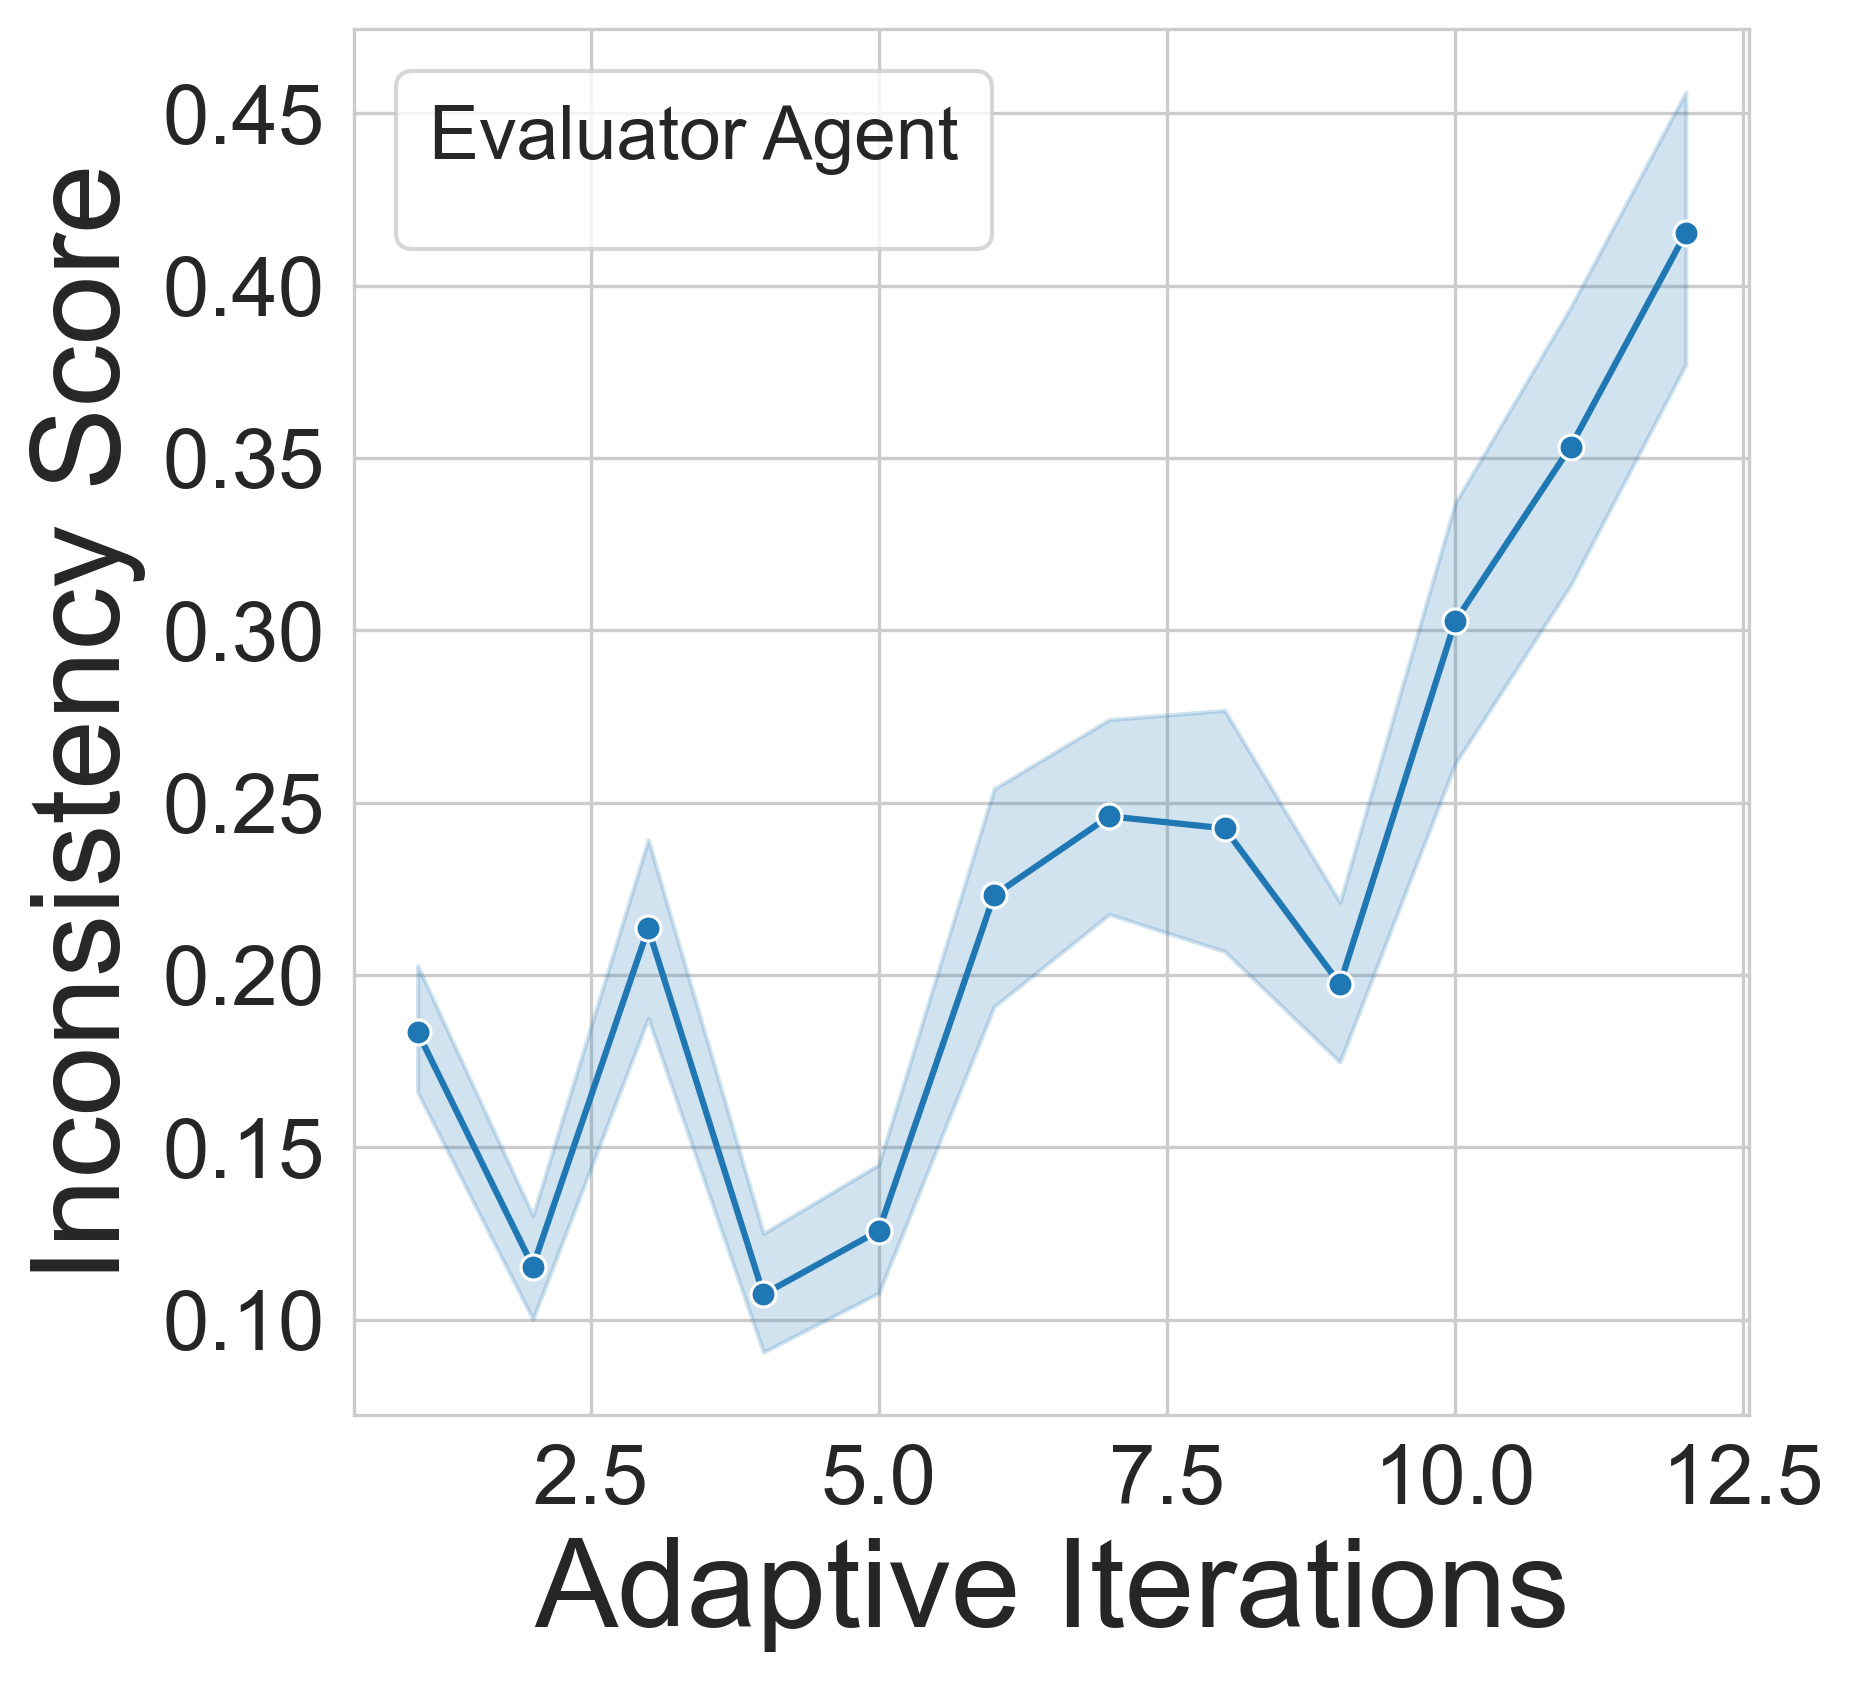

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt


# Set style for paper-quality plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 30,
    'axes.titlesize': 16,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20,
    'legend.title_fontsize': 18
})
# Create figure with higher DPI for paper quality
plt.figure(figsize=(6, 6), dpi=300)

sns.lineplot(
    combined_df, x = "iteration", y = "consistency_score", marker="o", err_style="band", errorbar=('ci', 75)
)
plt.xlabel("Adaptive Iterations",)
plt.ylabel("Inconsistency Score")
# plt.ylim(0.3, 1)
plt.legend(title="Evaluator Agent")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig("")
plt.show()

In [55]:
# def create_lplot(combined_df: pd.DataFrame) -> go.Figure:
#     """
#     Given a DataFrame containing TSNE embeddings, topic groups, and iteration labels,
#     create a scatter plot showing model data colored by topic group, with base data shown
#     in semi-transparent gray, and topic medoids labeled.
    
#     Args:
#         combined_df (pd.DataFrame): A DataFrame containing columns:
#             - "TSNE1", "TSNE2" : Coordinates from TSNE.
#             - "iteration" : Numeric iteration value.
#             - "ColorGroup" : Assigned grouping (e.g., "Base", or any topic group).
#             - "Formatted_Question" : Pre-formatted text for hover.
#             - "IterationLabel" : String label for iteration.
    
#     Returns:
#         go.Figure: The Plotly figure.
#     """
#     import numpy as np
#     from sklearn.metrics import pairwise_distances
#     import plotly.express as px
#     import plotly.graph_objects as go

#     # Separate base vs. model for layered plotting
#     base_data = combined_df[combined_df["iteration"] < 0].copy()
#     model_data = combined_df[combined_df["iteration"] >= 0].copy()

#     # Main scatter: model data colored by ColorGroup
#     fig = px.scatter(
#         model_data,
#         x="TSNE1",
#         y="TSNE2",
#         color="ColorGroup",
#         hover_data={
#             "TSNE1": False,
#             "TSNE2": False,
#             "IterationLabel": True,
#             "ColorGroup": True,
#             "Formatted_Question": True
#         },
#         width=1100,
#         height=600,
#     )

#     # Add base data in light gray
#     fig.add_trace(
#         go.Scatter(
#             x=base_data["TSNE1"],
#             y=base_data["TSNE2"],
#             mode="markers",
#             marker=dict(color="rgba(160,160,160,0.3)", size=10),
#             name="Initial Static Questions",
#             text=base_data["Formatted_Question"],
#             hoverinfo="text",
#             showlegend=False,
#         )
#     )

#     # Label each topic group with its medoid, skipping Base or Other
#     groups = model_data["ColorGroup"].unique()
#     for grp in groups:
#         if grp == "Base" or grp == "Other":
#             continue
#         subset_df = model_data[model_data["ColorGroup"] == grp]
#         if subset_df.empty:
#             continue

#         coords_g = subset_df[["TSNE1", "TSNE2"]].values
#         dists = pairwise_distances(coords_g, metric="euclidean")
#         sum_dists = dists.sum(axis=1)
#         medoid_idx = np.argmin(sum_dists)
#         medoid_x, medoid_y = coords_g[medoid_idx]

#         fig.add_annotation(
#             x=medoid_x,
#             y=medoid_y,
#             text=grp,
#             showarrow=True,
#             arrowhead=0,
#             arrowwidth=4,
#             arrowcolor="rgba(136,136,136,0.5)",
#             ax=40 if grp == "Politics & Econ" else (
#                 -40 if grp == "Energy & Environ" else
#                 -40 if grp == "AI & CS" else
#                 140 if grp == "Manufacturing" else
#                 60 if grp == "Media" else 0  
#             ),
#             ay=30 if grp == "Politics & Econ" else (
#                 -65 if grp == "Energy & Environ" else
#                 -55 if grp == "Ag & Biotech" else
#                 -45 if grp == "Manufacturing" else
#                 -45
#             ),
#             font=dict(
#                 size=24,
#                 color="#222",
#                 family="Arial",
#                 weight="bold"
#             ),
#             bgcolor="white",
#             bordercolor="#c7c7c7",
#             borderwidth=2,
#             borderpad=6,
#             opacity=0.9,
#         )

#     # Style updates
#     fig.update_layout(
#         plot_bgcolor="white",
#         font=dict(size=20),
#         margin=dict(t=20),
#         xaxis=dict(showticklabels=False, showgrid=True),
#         yaxis=dict(showticklabels=False, showgrid=True),
#     )
#     fig.update_traces(marker=dict(size=10), showlegend=False)

#     return fig

In [56]:
# fig = create_lplot(combined_df)
# fig.show()

In [57]:
# combined_df_deepseek = analyze_model_topics_with_cache(
#     csv_path="/Users/davisbrown/adaptive_evals/tasks/cond_100/deepseek-v3/deepseek_chat_20250127_212346.csv"
# )
# fig = create_lplot(combined_df_deepseek)
# fig.show()

In [58]:
def create_interactive_lplot(combined_df: pd.DataFrame) -> None:
    """
    Creates an interactive plot with sliders to adjust both:
    1. The position of each topic group label (ax, ay offsets)
    2. The actual medoid/centroid position (x, y coordinates)
    
    Args:
        combined_df (pd.DataFrame): A DataFrame containing TSNE embeddings, topic groups, etc.
    """
    import numpy as np
    from sklearn.metrics import pairwise_distances
    import plotly.express as px
    import plotly.graph_objects as go
    import ipywidgets as widgets
    from IPython.display import display
    
    # Separate base vs. model for layered plotting
    base_data = combined_df[combined_df["iteration"] < 0].copy()
    model_data = combined_df[combined_df["iteration"] >= 0].copy()
    
    # Get unique topic groups (excluding Other)
    groups = [grp for grp in model_data["ColorGroup"].unique() 
              if grp != "Other"]
    
    # Calculate medoids for each group
    original_medoids = {}
    for grp in groups:
        subset_df = model_data[model_data["ColorGroup"] == grp]
        if subset_df.empty:
            continue
            
        coords_g = subset_df[["TSNE1", "TSNE2"]].values
        dists = pairwise_distances(coords_g, metric="euclidean")
        sum_dists = dists.sum(axis=1)
        medoid_idx = np.argmin(sum_dists)
        original_medoids[grp] = coords_g[medoid_idx]
    
    # Calculate centroid for base data
    if not base_data.empty:
        base_coords = base_data[["TSNE1", "TSNE2"]].values
        base_centroid = base_coords.mean(axis=0)
        original_medoids["Base Dataset"] = base_centroid
        groups.append("Base Dataset")  # Add Base Dataset to groups
    
    # Print original medoid coordinates for reference
    print("Original Medoid/Centroid Coordinates:")
    for grp, coords in original_medoids.items():
        print(f"{grp}: ({coords[0]:.2f}, {coords[1]:.2f})")
    
    # Create initial figure
    def create_figure(settings):
        fig = px.scatter(
            model_data,
            x="TSNE1",
            y="TSNE2",
            color="ColorGroup",
            hover_data={
                "TSNE1": False,
                "TSNE2": False,
                "IterationLabel": True,
                "ColorGroup": True,
                "Formatted_Question": True
            },
            width=950,
            height=600,
        )
        
        # Print the color for each group
        print("Color for each group:")
        for i, grp in enumerate(fig.data):
            if grp.name != "Initial Static Questions":
                print(f"{grp.name}: {grp.marker.color}")
        
        # Add base data in light gray
        fig.add_trace(
            go.Scatter(
                x=base_data["TSNE1"],
                y=base_data["TSNE2"],
                mode="markers",
                marker=dict(color="rgba(160,160,160,0.3)", size=10),
                name="Initial Static Questions",
                text=base_data["Formatted_Question"],
                hoverinfo="text",
                showlegend=False,
            )
        )
        
        # Add annotations with current settings
        for grp in groups:
            if grp not in original_medoids:
                continue
            
            # Get adjusted medoid position
            medoid_x = settings[f"{grp}_medoid_x"]
            medoid_y = settings[f"{grp}_medoid_y"]
            
            # Get label offset
            ax_offset = settings[f"{grp}_label_x"]
            ay_offset = settings[f"{grp}_label_y"]
            
            # Special styling for Base Dataset label
            font_style = dict(
                size=24,
                color="#222",
                family="Arial",
                weight="bold"
            )
            
            bg_color = "white"
            if grp == "Base Dataset":
                font_style["color"] = "#555"
                font_style["size"] = 22
                bg_color = "rgba(240,240,240,0.9)"
            
            fig.add_annotation(
                x=medoid_x,
                y=medoid_y,
                text=grp if grp != "Base Dataset" else "Initial Static Questions",
                showarrow=True,
                arrowhead=0,
                arrowwidth=4,
                arrowcolor="rgba(136,136,136,0.5)",
                ax=ax_offset,
                ay=ay_offset,
                font=font_style,
                bgcolor=bg_color,
                bordercolor="#c7c7c7",
                borderwidth=2,
                borderpad=6,
                opacity=0.9,
            )
        
        # Style updates
        # Style updates
        # Style updates
        fig.update_layout(
            plot_bgcolor="rgba(250, 245, 235, 0.3)",  # Even lighter tan with more transparency
            font=dict(size=20),
            margin=dict(t=20),
            xaxis=dict(
                showticklabels=False, 
                showgrid=True,
                gridcolor='rgba(200, 200, 200, 0.5)',
                gridwidth=0.5,
                dtick=5  # More dense grid lines (smaller spacing)
            ),
            yaxis=dict(
                showticklabels=False, 
                showgrid=True,
                gridcolor='rgba(200, 200, 200, 0.5)',
                gridwidth=0.5,
                dtick=5  # More dense grid lines (smaller spacing)
            ),
        )        
        fig.update_traces(marker=dict(size=10), showlegend=False)
        # Save figure to PDF
        fig.write_image("cluster_visualization_attempt.pdf", width=950, height=600, scale=2)

        
        return fig
    
    # Initial settings
    initial_settings = {}
    # Initialize with specific values for each group
    initial_settings = {
        'Sports_medoid_x': -9.89310359954834,
        'Sports_medoid_y': -27.832265853881836,
        'Sports_label_x': -90,
        'Sports_label_y': -45,
        'Tech & AI_medoid_x': -37.084150314331055,
        'Tech & AI_medoid_y': -0.9059154987335205,
        'Tech & AI_label_x': -5,
        'Tech & AI_label_y': -90,
        'Politics & Econ_medoid_x': -7.2268218994140625,
        'Politics & Econ_medoid_y': 3.8201920986175537,
        'Politics & Econ_label_x': -165,
        'Politics & Econ_label_y': 135,
        'Media_medoid_x': 13.402406692504883,
        'Media_medoid_y': 2.582458734512329,
        'Media_label_x': 60,
        'Media_label_y': -45,
        'Energy & Environ_medoid_x': -5.9543561935424805,
        'Energy & Environ_medoid_y': 14.827591896057129,
        'Energy & Environ_label_x': -40,
        'Energy & Environ_label_y': -85,
        'Ag & Biotech_medoid_x': 49.48267364501953,
        'Ag & Biotech_medoid_y': -6.178792953491211,
        'Ag & Biotech_label_x': -35,
        'Ag & Biotech_label_y': -90,
        'Manufacturing_medoid_x': 15.73799991607666,
        'Manufacturing_medoid_y': 17.127296447753906,
        'Manufacturing_label_x': 140,
        'Manufacturing_label_y': -45,
        'Base Dataset_medoid_x': 2.814713716506958,
        'Base Dataset_medoid_y': -13.744531631469727,
        'Base Dataset_label_x': 135,
        'Base Dataset_label_y': 80,
    }
    
    # For any groups not explicitly defined above, use original medoid positions
    for grp in groups:
        if f"{grp}_medoid_x" not in initial_settings:
            initial_settings[f"{grp}_medoid_x"] = original_medoids[grp][0]
            initial_settings[f"{grp}_medoid_y"] = original_medoids[grp][1]
            initial_settings[f"{grp}_label_x"] = 0
            initial_settings[f"{grp}_label_y"] = -45
    
    # Create sliders for each group
    sliders = {}
    for grp in groups:
        # Medoid position sliders
        sliders[f"{grp}_medoid_x"] = widgets.FloatSlider(
            value=initial_settings[f"{grp}_medoid_x"],
            min=initial_settings[f"{grp}_medoid_x"] - 20,
            max=initial_settings[f"{grp}_medoid_x"] + 20,
            step=0.5,
            description=f"Medoid X:" if grp != "Base Dataset" else "Center X:",
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='500px')
        )
        
        sliders[f"{grp}_medoid_y"] = widgets.FloatSlider(
            value=initial_settings[f"{grp}_medoid_y"],
            min=initial_settings[f"{grp}_medoid_y"] - 20,
            max=initial_settings[f"{grp}_medoid_y"] + 20,
            step=0.5,
            description=f"Medoid Y:" if grp != "Base Dataset" else "Center Y:",
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='500px')
        )
        
        # Label offset sliders
        sliders[f"{grp}_label_x"] = widgets.IntSlider(
            value=initial_settings[f"{grp}_label_x"],
            min=-200,
            max=200,
            step=5,
            description=f"Label X:" if grp != "Base Dataset" else "Base Label X:",
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='500px')
        )
        
        sliders[f"{grp}_label_y"] = widgets.IntSlider(
            value=initial_settings[f"{grp}_label_y"],
            min=-200,
            max=200,
            step=5,
            description=f"Label Y:" if grp != "Base Dataset" else "Base Label Y:",
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='500px')
        )
    
    # Create output widget for the plot
    plot_output = widgets.Output()
    
    # Function to update the plot when sliders change
    def update_plot(*args):
        current_settings = {key: slider.value for key, slider in sliders.items()}
        with plot_output:
            plot_output.clear_output(wait=True)
            fig = create_figure(current_settings)
            fig.show()
    
    # Connect sliders to the update function
    for slider in sliders.values():
        slider.observe(update_plot, names='value')
    
    # Create accordion for each group's sliders
    accordion_items = []
    for grp in groups:
        group_box = widgets.VBox([
            widgets.HTML(value=f"<b>Original position:</b> ({original_medoids[grp][0]:.2f}, {original_medoids[grp][1]:.2f})"),
            sliders[f"{grp}_medoid_x"], 
            sliders[f"{grp}_medoid_y"],
            widgets.HTML(value="<b>Label offset:</b>"),
            sliders[f"{grp}_label_x"], 
            sliders[f"{grp}_label_y"]
        ])
        accordion_items.append((
            grp if grp != "Base Dataset" else "Initial Static Questions", 
            group_box
        ))
    
    accordion = widgets.Accordion(children=[item[1] for item in accordion_items])
    for i, (title, _) in enumerate(accordion_items):
        accordion.set_title(i, title)
    
    # Create a button to print current settings (useful for copying values)
    def print_settings(b):
        print("Current settings:")
        for key, slider in sliders.items():
            print(f"'{key}': {slider.value},")
    
    print_button = widgets.Button(
        description='Print Current Settings',
        button_style='info',
        tooltip='Print the current settings'
    )
    print_button.on_click(print_settings)
    
    # Create a reset button to restore original medoid positions
    def reset_medoids(b):
        for grp in groups:
            sliders[f"{grp}_medoid_x"].value = original_medoids[grp][0]
            sliders[f"{grp}_medoid_y"].value = original_medoids[grp][1]
    
    reset_button = widgets.Button(
        description='Reset Medoid Positions',
        button_style='warning',
        tooltip='Reset medoid positions to original values'
    )
    reset_button.on_click(reset_medoids)
    
    # Display everything
    display(accordion, widgets.HBox([print_button, reset_button]), plot_output)
    
    # Initial plot
    update_plot()
    
    return sliders  # Return sliders in case you want to access them later

In [59]:
create_interactive_lplot(combined_df)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Accordion(children=(VBox(children=(HTML(value='<b>Original position:</b> (-9.89, -27.83)'), FloatSlider(value=…

Output()

{'Sports_medoid_x': FloatSlider(value=-9.89310359954834, description='Medoid X:', layout=Layout(width='500px'), max=10.10689640045166, min=-29.89310359954834, step=0.5, style=SliderStyle(description_width='initial')),
 'Sports_medoid_y': FloatSlider(value=-27.832265853881836, description='Medoid Y:', layout=Layout(width='500px'), max=-7.832265853881836, min=-47.832265853881836, step=0.5, style=SliderStyle(description_width='initial')),
 'Sports_label_x': IntSlider(value=-90, description='Label X:', layout=Layout(width='500px'), max=200, min=-200, step=5, style=SliderStyle(description_width='initial')),
 'Sports_label_y': IntSlider(value=-45, description='Label Y:', layout=Layout(width='500px'), max=200, min=-200, step=5, style=SliderStyle(description_width='initial')),
 'Tech & AI_medoid_x': FloatSlider(value=-37.084150314331055, description='Medoid X:', layout=Layout(width='500px'), max=-17.084150314331055, min=-57.084150314331055, step=0.5, style=SliderStyle(description_width='initia

In [14]:
# create_interactive_lplot(combined_df_deepseek)